# MeRN Quick Start Tutorial

## Metabolic Representation Net (MeRN)

Single-cell RNA-seq data provides rich information about gene expression across thousands of cells, but interpreting **cellular metabolism** from transcriptomic data alone is challenging. Many metabolic processes are coordinated across genes and reactions, making them difficult to capture with standard dimensionality reduction methods.

**Metabolic Representation Net (MeRN)** is a graph-guided variational autoencoder designed to infer metabolic state from single-cell transcriptomic data.

Standard VAEs such as **scVI** learn low-dimensional latent representations of cells and decode them to gene-level parameters using flexible neural networks. While these models capture complex transcriptional structure, the latent dimensions are not explicitly linked to metabolic processes.

MeRN introduces a **metabolic prior** by leveraging a metabolic reaction graph, where:

- **nodes** represent metabolic reactions  
- **edges** connect reactions that share metabolites

A graph VAE learns embeddings of this reaction network, and the cell-level latent space is decomposed into two components:

• **Metabolic variation**: variation explained by metabolic reactions  
• **Background variation**: non-metabolic transcriptional variation

This structure links latent dimensions to **reaction activity and enzyme-coding genes**, enabling interpretable metabolic representations.

In this tutorial, we apply MeRN to a mouse embryogenesis single-cell RNA-seq dataset. We will:

1. Load the preprocessed wild-type embryogenesis dataset.
2. Fit or load a pretrained MeRN model.
3. Extract metabolic and background cell embeddings.
4. Analyze the metabolic latent space with UMAP and clustering.
5. Decode reaction activity for every cell.
6. Aggregate reaction activity into KEGG pathway scores.
7. Build data-driven pathways (DDPs), which group graph-connected reactions with coordinated activity across cells.
8. Compare reaction, KEGG pathway, and DDP activity across metabolic clusters.
9. Visualize glycolysis/gluconeogenesis on KEGG pathway graphs, colored by DDP membership and by differential reaction activity.
10. Expand a KEGG pathway by plotting all reactions in DDPs connected to glycolysis.
11. Compare DDP structure between wild-type and *Folr1* knockout embryos in a matched metabolic
    state. Steps 1-10 use the wild type alone; the knockout enters only as a table of decoded
    reaction activity.

The tutorial emphasizes DDPs as a data-driven interpretation layer between individual reactions and broad canonical pathways. Reactions are highly granular, while KEGG pathways are predefined and often broad. DDPs provide coordinated metabolic reaction programs learned from the data and constrained by the metabolic graph.

![MeRN Architecture](figures/mern_architecture.png)

### Files and Folder Structure
```text
tutorials/
├── MeRN_tutorial.ipynb
├── data/
│   ├── main_wt_anndata_pp_subsample.h5ad.gz     wild-type cells: log1p `X`, raw `counts_RNA`
│   ├── folr1_anndata_subsample.h5ad.gz          Folr1 knockout cells, same gene space
│   └── folr1_average_enzyme_activity.csv.gz     knockout reaction activity
└── model/
    ├── average_enzyme_activity.csv.gz           wild-type reaction activity
    ├── mern_rep_0/
    │   ├── model.pt.gz                          pretrained checkpoint
    │   ├── metabolic_clustering_0.4.csv         published wild-type metabolic states
    │   └── reference_mapped/
    │       ├── metabolic_clustering.csv         both genotypes on the wild-type states
    │       └── metabolic_umap.csv               shared metabolic UMAP
    └── mern_rep_1/
        └── model.pt.gz                          second replicate, for the decoding demo
```

In [1]:
from scvi.train._callbacks import SaveCheckpoint
from mern import MERN
import mern.support as mern_support
import anndata as ad
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import os
import plotly.colors as pc
from contextlib import contextmanager
from IPython.display import display

/opt/homebrew/Caskroom/miniforge/base/envs/mern_skin/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_new_model = False
clustering_res = 0.4
chosen_rep = 0
n_reps = 2

base_path_data = 'data'
base_path_model = 'model'
base_path_figures = 'figures'

wt_adata_file = 'main_wt_anndata_pp_subsample.h5ad.gz'
folr1_adata_file = 'folr1_anndata_subsample.h5ad.gz'
folr1_activity_file = 'folr1_average_enzyme_activity.csv.gz'

suffix = f'_rep{chosen_rep}'
metabolic_key = f"X_mern_metabolic{suffix}"
background_key = f"X_mern_background{suffix}"
metabolic_umap_key = f"X_umap_metabolic{suffix}"
background_umap_key = f"X_umap_background{suffix}"
graph_key = f"graph{suffix}"

### Unpacking the Checkpoints

The replicate checkpoints are gzipped and must be decompressed in place the first time the tutorial is run.


In [3]:
import gzip
import shutil
from pathlib import Path

for archive in sorted(Path(base_path_model).glob('mern_rep_*/model.pt.gz')):
    checkpoint = archive.with_suffix('')
    if checkpoint.exists():
        continue
    print(f'unpacking {archive}')
    with gzip.open(archive) as src, open(checkpoint, 'wb') as dst:
        shutil.copyfileobj(src, dst)

print('checkpoints ready:', sorted(p.parent.name for p in Path(base_path_model).glob('mern_rep_*/model.pt')))


checkpoints ready: ['mern_rep_0', 'mern_rep_1']


### Figure Colors

A small color registry keeps the figures in this tutorial consistent.

In [4]:
TEXT_COLOR = '#222222'
STRUCTURE_COLOR = '#666666'
BACKGROUND_COLOR = '#A7ADB8'
MISSING_COLOR = '#CFCFCF'
OBSERVED_COLOR = '#0072B2'
HIGHLIGHT_COLOR = '#D55E00'

METHOD_PALETTE = {
    'mern': '#0072B2',
    'rna': '#E69F00',
    'scrna': '#009E73',
    'prot': '#222222',
    'kegg_metroscreen': '#CC79A7',
    'compass': '#56B4E9',
}

GENOTYPE_PALETTE = {
    'WT': '#7A7A7A',
    'Folr1': '#8C6BB1',
    'Folr1 KO': '#8C6BB1',
}

GERMLAYER_PALETTE = {
    'Epiblast': '#000000',
    'PrimitiveStreak': '#808080',
    'GermCell': '#DB083D',
    'Endoderm': '#F5F200',
    'XMesoderm': '#00C4ED',
    'AxialMesoderm': '#0000FC',
    'Mesoderm': '#910299',
    'NeuralEctoderm': '#008C2A',
    'NonNeuralEctoderm': '#334513',
}

PHASE_PALETTE = {
    'G0/G1': '#4C78A8',
    'S': '#F2CF5B',
    'G2': '#72B7B2',
    'M': '#B279A2',
}

HEATMAP_CMAP = mpl.colormaps['viridis']

EMBRYO_DDP_PALETTE = {
    'ddp_3': '#2E91E5',
    'ddp_32': '#E15F99',
    'ddp_37': '#1CA71C',
    'ddp_44': '#FB0D0D',
    'ddp_46': '#DA16FF',
    'ddp_53': '#222A2A',
    'ddp_58': '#B68100',
    'ddp_59': '#750D86',
    'ddp_66': '#EB663B',
    'ddp_83': '#511CFB',
    'ddp_89': '#00A08B',
    'ddp_90': '#FB00D1',
    'ddp_91': '#FC0080',
    'ddp_92': '#B2828D',
    'ddp_94': '#6C7C32',
    'ddp_100': '#778AAE',
    'ddp_103': '#862A16',
    'ddp_111': '#A777F1',
    'ddp_113': '#620042',
    'ddp_116': '#1616A7',
    'ddp_118': '#DA60CA',
    'ddp_123': '#6C4516',
    'ddp_124': '#0D2A63',
    'ddp_127': '#AF0038',
}

def reset_plotting_defaults():
    """Editable-text vector output and a consistent typeface."""
    mpl.rcdefaults()
    sns.reset_defaults()
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'axes.spines.top': False,
        'axes.spines.right': False,
        'legend.frameon': False,
        'figure.dpi': 150,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
    })

reset_plotting_defaults()

def styled_theme(**kwargs):
    """`sns.set_theme` that keeps this tutorial's typeface and editable-text vector output."""
    kwargs.setdefault('font', 'Arial')
    rc = {
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
        'legend.frameon': False,
    }
    rc.update(kwargs.pop('rc', {}))
    sns.set_theme(rc=rc, **kwargs)

def ddp_palette_sequence(labels):
    """Colors for a set of DDP labels: the registry first, Dark24 for the rest.

    Unregistered DDPs take Dark24 colors the registry has not already claimed, so a DDP set that
    mixes the two does not reuse one color for two pathways.
    """
    categories = list(pd.Series(labels).dropna().unique())
    claimed = {EMBRYO_DDP_PALETTE[c] for c in categories if c in EMBRYO_DDP_PALETTE}
    spare = [c for c in pc.qualitative.Dark24 if c not in claimed] or list(pc.qualitative.Dark24)

    sequence, next_spare = [], 0
    for label in categories:
        if label in EMBRYO_DDP_PALETTE:
            sequence.append(EMBRYO_DDP_PALETTE[label])
        else:
            sequence.append(spare[next_spare % len(spare)])
            next_spare += 1
    return sequence

def ddp_color_map_for(labels):
    """DDP label -> color, for the `ddp_color_map` argument of the pathway plots."""
    categories = list(pd.Series(labels).dropna().unique())
    return dict(zip(categories, ddp_palette_sequence(categories)))

@contextmanager
def ddp_pathway_palette(labels):
    """The pathway plots color discrete edge labels from Plotly's Set1, in order of first
    appearance. Swap the DDP registry in for the duration of one plot."""
    original = pc.qualitative.Set1
    pc.qualitative.Set1 = ddp_palette_sequence(labels)
    try:
        yield
    finally:
        pc.qualitative.Set1 = original

# --- Pathway plot labels ---------------------------------------------------
KEY_METABOLITE_IDS = [
    'cpd:C00267',  # alpha-D-Glucose
    'cpd:C00031',  # D-Glucose
    'cpd:C00668',  # alpha-D-Glucose 6-phosphate
    'cpd:C00085',  # D-Fructose 6-phosphate
    'cpd:C00354',  # D-Fructose 1,6-bisphosphate
    'cpd:C00111',  # Glycerone phosphate
    'cpd:C00118',  # D-Glyceraldehyde 3-phosphate
    'cpd:C00236',  # 3-Phospho-D-glyceroyl phosphate
    'cpd:C00197',  # 3-Phospho-D-glycerate
    'cpd:C00631',  # 2-Phospho-D-glycerate
    'cpd:C00074',  # Phosphoenolpyruvate
    'cpd:C00022',  # Pyruvate
    'cpd:C00186',  # (S)-Lactate
]

ANCHOR_METABOLITE_IDS = ['cpd:C00267', 'cpd:C00022', 'cpd:C00186']

def pathway_compound_nodes(dataset, pathway=None, rxns=None):
    """The compound nodes a pathway plot will draw.

    Mirrors the node construction inside `kegg_pathway_plot` / `custom_pathway_plot`, so a label
    choice can be checked against the figure before plotting instead of silently going missing.
    """
    if (pathway is None) == (rxns is None):
        raise ValueError('pass exactly one of `pathway` or `rxns`')
    wanted = set(rxns) if rxns is not None else None
    nodes = set()
    for reaction in dataset.rxns:
        if wanted is None:
            in_pathway = any(
                pathway in [p[0] for p in dataset.rxn_info[r.split('rn:')[1]]['PATHWAY']]
                for r in reaction.name.split(' ')
            )
            if not in_pathway:
                continue
        elif reaction.name not in wanted:
            continue
        nodes.update(compound.name for compound in reaction.substrates)
        nodes.update(compound.name for compound in reaction.products)
    return nodes


def metabolite_labels(dataset, pathway=None, rxns=None, require_anchors=True):
    """`labeled_nodes` for a pathway plot: the key metabolites this particular plot contains.

    A compound ID that is not a node in the plot would simply never be drawn, so when
    `require_anchors` is set a missing anchor raises instead of quietly losing its label.
    """
    present = pathway_compound_nodes(dataset, pathway=pathway, rxns=rxns)
    if require_anchors:
        missing = [c for c in ANCHOR_METABOLITE_IDS if c not in present]
        if missing:
            raise ValueError(
                f'anchor metabolites absent from this plot: {missing}. '
                'Check the IDs against `dataset.compound_info`.'
            )
    return [c for c in KEY_METABOLITE_IDS if c in present]


### Loading the WT Dataset

The wild-type dataset here is a subsample of the original full embryogenesis data `main_wt_anndata_pp.h5ad.gz`. The pretrained models are the published ones.

Cells outside the embryo proper (the `Blood&Vas`, `XEctoderm`, and `XEndoderm`
germ layers) and genes detected in fewer than 100 cells were already removed from the full object,
so no further preprocessing is needed here.

The feature space is the object's own `highly_variable_metabolic` / `highly_variable_background`
flags, sorted (800 metabolic & 5,000 background genes).

`X` is already log1p-normalized; `layers['counts_RNA']` holds the raw counts the model reads.

In [5]:
rna_full = ad.read_h5ad(f'{base_path_data}/{wt_adata_file}')

dataset = mern_support.KeggKGMLMetabolicDataset(species='mouse', capitalize=False)
dataset.add_module_info(rna_full)

features_to_use = sorted(
    rna_full.var_names[
        rna_full.var['highly_variable_metabolic'] | rna_full.var['highly_variable_background']
    ]
)
rna = rna_full[:, features_to_use].copy()

met_g = dataset.metabolic_topology(rna, self_loops=False)
dataset.add_rxn_module_info(rna, met_g)
dataset.add_rxn_module_info(rna_full, met_g)
rxn_genes = dataset.get_rxn_genes_all()

del rna_full.layers['counts_RNA']
rna_full.layers['log1p_norm'] = rna_full.X
rna.layers['log1p_norm'] = rna.X

rxn_info = rna.uns["Reaction Info"]
rxn_ids = rxn_info.index.to_list()

print(rna)
print(rna.var['Metabolic Gene'].value_counts())


AnnData object with n_obs × n_vars = 6000 × 5800
    obs: 'nCount_RNA', 'nFeature_RNA', 'log_count', 'percent.mt', 'sex', 'embryo_id', 'sample_group', 'timepoint', 'cell_type', 'germlayer'
    var: 'names', 'n_cells', 'Gene Reactions', 'Metabolic Gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_metabolic', 'highly_variable_background'
    uns: 'hvg', 'Reaction Info'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts_RNA', 'log1p_norm'
Metabolic Gene
Non-metabolic    5000
Metabolic         800
Name: count, dtype: int64


In [6]:
for adata_obj in [rna, rna_full]:
    for col in ('cell_type', 'germlayer'):
        if col in adata_obj.obs:
            adata_obj.obs[col] = adata_obj.obs[col].astype('category')

    if 'germlayer' in adata_obj.obs:
        adata_obj.uns['germlayer_colors'] = [
            GERMLAYER_PALETTE.get(cat, MISSING_COLOR)
            for cat in adata_obj.obs['germlayer'].cat.categories
        ]


### Loading or Training a MeRN Model
You can either train a fresh MeRN model or load a saved checkpoint. When training, set loss weights and KL schedules, configure checkpointing, and fit the model with early stopping. After training, reload the best checkpoint, save the training history, and plot key loss curves to verify convergence. If not training, load the pretrained model and history, then re-instantiate the MeRN model with the chosen architecture.

In [7]:
if train_new_model:
    data_dir = 'models'

    plan_kwargs={
        "max_kl_weight": 0.001,
        "graph_kl_weight": 0.1,
        "data_elbo_weight": 1.0,
        "graph_elbo_weight": 0.2,
        "rxn_genes_weight": 0.5,
        "background_to_metabolic_weight": 30000,
        "lr": 0.002,
        "n_steps_kl_warmup": 0,
        "n_epochs_kl_warmup": None
    }

    checkpointing = SaveCheckpoint(
        dirpath=f'{data_dir}/scvi_log_3', monitor="validation_loss", load_best_on_end=False, check_nan_gradients=False
    )
    MERN.setup_anndata(rna, layer='counts_RNA', batch_key=None)
    mern = MERN(rna, met_g, rxn_genes, n_hidden=256, n_layers=2, n_metabolic_dim=25, n_background_dim=15, encode_covariates=False, strict_met_back_separation=True, rxn_genes_bias=True)
    mern.train(accelerator="auto", max_epochs=400, early_stopping=True, early_stopping_monitor="validation_loss", plan_kwargs=plan_kwargs, callbacks = [checkpointing])

    best_mern = MERN.load(checkpointing.best_model_path, rna, accelerator='auto')
else:
    models_by_rep = {}
    for rep in range(n_reps):
        try:
            models_by_rep[rep] = MERN.load(
                f'{base_path_model}/mern_rep_{rep}', rna, accelerator='cpu'
            )
        except Exception as error:
            print(f'replicate {rep} unavailable ({type(error).__name__})')

    if chosen_rep not in models_by_rep:
        raise RuntimeError(f'replicate {chosen_rep} is required for the embeddings below')

    models = list(models_by_rep.values())
    mern = models_by_rep[chosen_rep]
    print(f'{len(models)} of {n_reps} replicates loaded')


INFO     File model/mern_rep_0/model.pt already downloaded                                                         
INFO     File model/mern_rep_1/model.pt already downloaded                                                         
2 of 2 replicates loaded


### Extracting the Embeddings

The model maps every cell into two latent spaces (a metabolic one tied to the reaction
graph, and a background one for everything else) and every reaction into a graph embedding.
`get_latent_representation` returns all three. It reports the mean of each latent distribution, so
repeated calls give identical answers.

In [8]:
metabolic_latent, background_latent, graph_embedding = mern.get_latent_representation(rna)

rna.obsm[metabolic_key] = metabolic_latent
rna.obsm[background_key] = background_latent
rna.uns[graph_key] = pd.DataFrame(graph_embedding, index=mern.vertex_names_ordered)

print(f'metabolic latent : {metabolic_latent.shape[0]:,} cells x {metabolic_latent.shape[1]} dims')
print(f'background latent: {background_latent.shape[0]:,} cells x {background_latent.shape[1]} dims')
print(f'graph embedding  : {graph_embedding.shape[0]:,} reactions x {graph_embedding.shape[1]} dims')

metabolic latent : 6,000 cells x 25 dims
background latent: 6,000 cells x 15 dims
graph embedding  : 1,213 reactions x 25 dims


## Metabolic and Background Embeddings

MeRN learns two latent embeddings for each cell:

### Background embedding

The background embedding captures non-metabolic transcriptional variation. This can include broad cell identity, developmental programs, technical structure, and other gene expression patterns that are not specifically explained through the metabolic reaction graph.

### Metabolic embedding

The metabolic embedding captures variation that is routed through the metabolic reaction graph. Cells that are transcriptionally similar can still separate in this space if they differ in inferred reaction activity or coordinated metabolic programs.

This embedding is the main space we use to identify metabolic cell states.

By comparing the metabolic and background embeddings, we can ask whether differences between cells are better explained by:

- general transcriptional variation
- metabolic reaction-level variation

In the next cells, we compute neighborhoods, UMAPs, and clusters separately for the metabolic and background embeddings.

### Embedding Clustering

/var/folders/rw/56p7h0px0xl82phr2ps3qy8c0000gn/T/ipykernel_27262/1585096667.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rna, neighbors_key='met_neighbors', key_added='met_leiden', resolution=clustering_res)


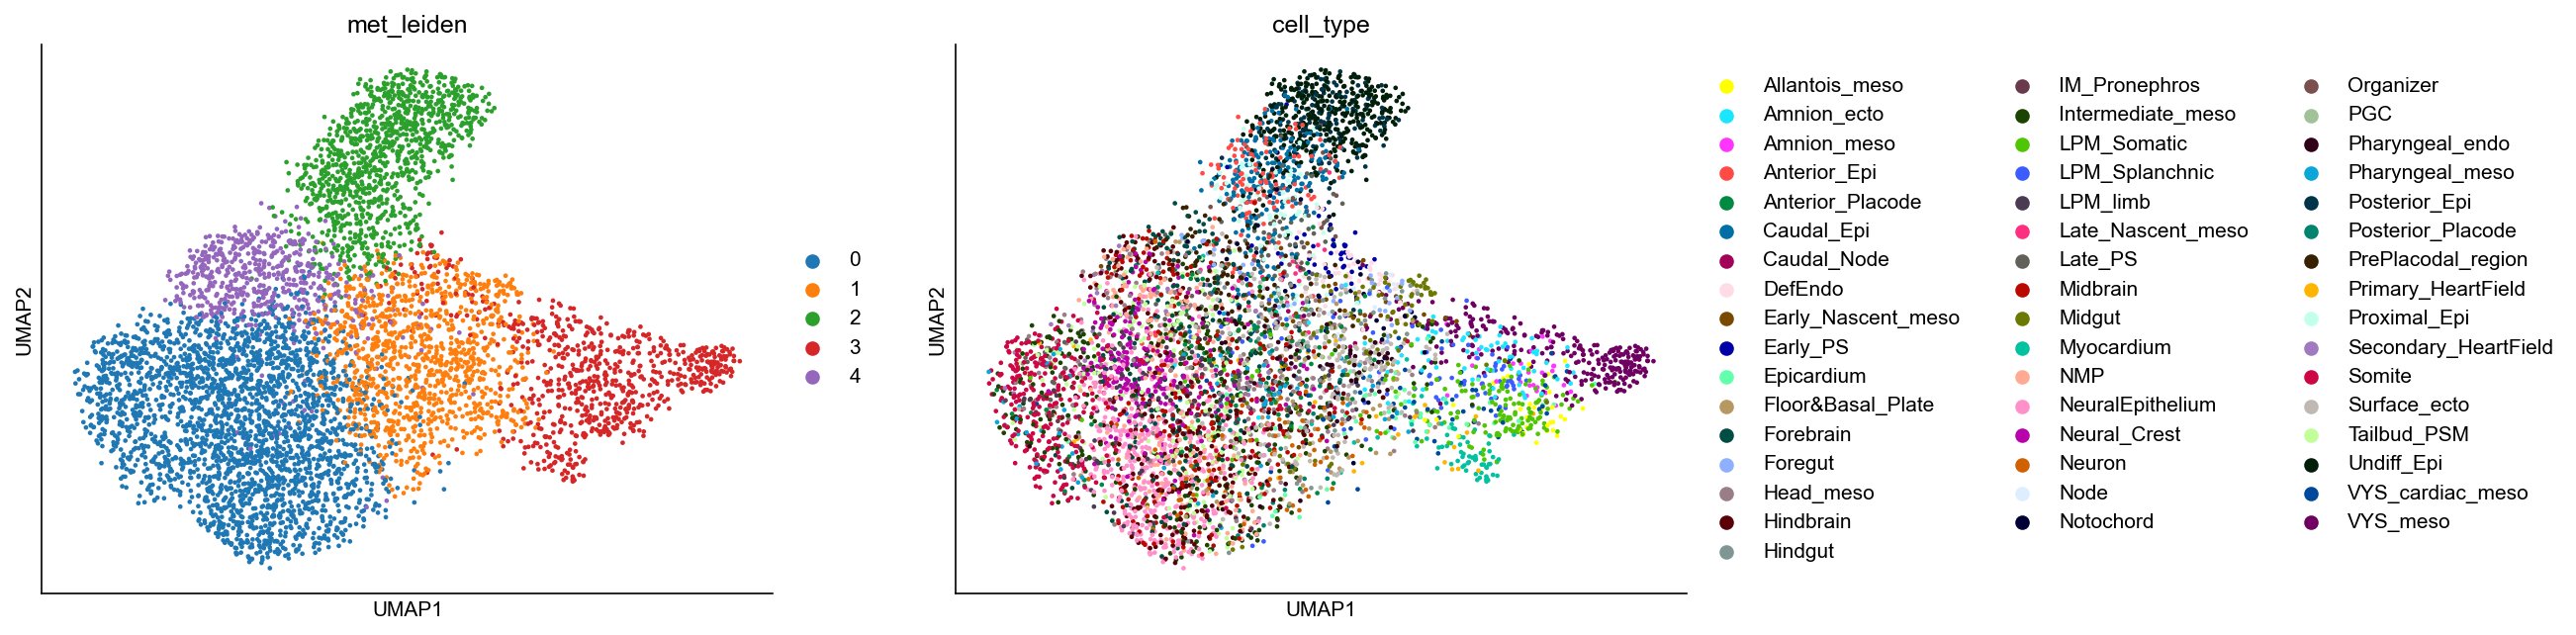

In [9]:
sc.pp.neighbors(rna, use_rep=metabolic_key, key_added='met_neighbors')
sc.tl.umap(rna, neighbors_key='met_neighbors')
sc.tl.leiden(rna, neighbors_key='met_neighbors', key_added='met_leiden', resolution=clustering_res)
sc.pl.umap(rna, color=['met_leiden', 'cell_type'], neighbors_key='met_neighbors')


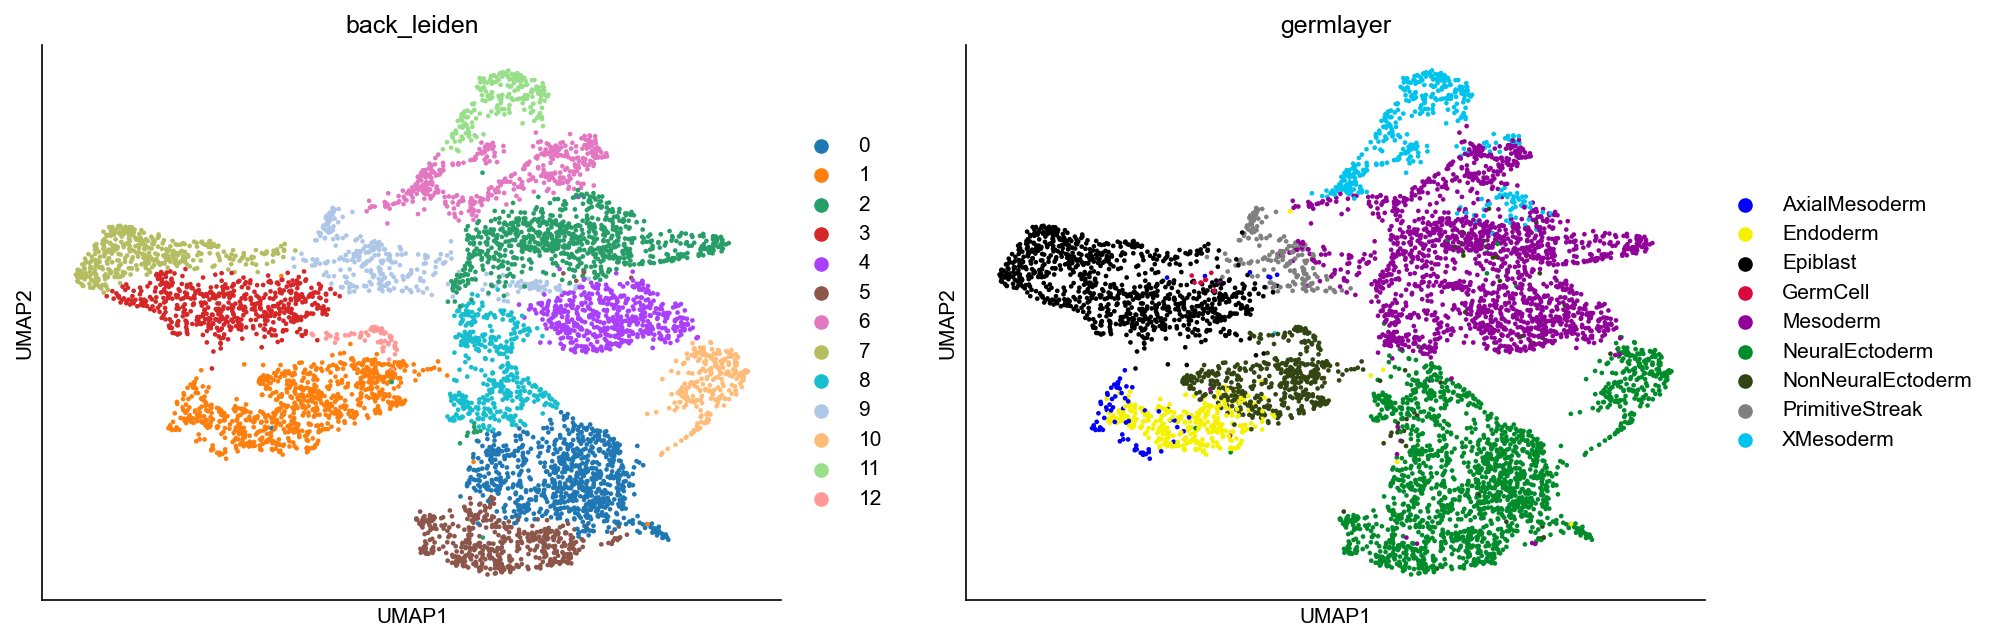

In [10]:
sc.pp.neighbors(rna, use_rep=background_key, key_added='back_neighbors')
sc.tl.umap(rna, neighbors_key='back_neighbors')
sc.tl.leiden(rna, neighbors_key='back_neighbors', key_added='back_leiden', resolution=clustering_res)
sc.pl.umap(rna, color=['back_leiden', 'germlayer'], neighbors_key='back_neighbors')


### Metabolic Embedding Analysis

We cluster cells in the MeRN metabolic embedding to identify metabolic states. To relate these states to embryonic development, we plot the proportion of cells in each metabolic cluster across timepoints.

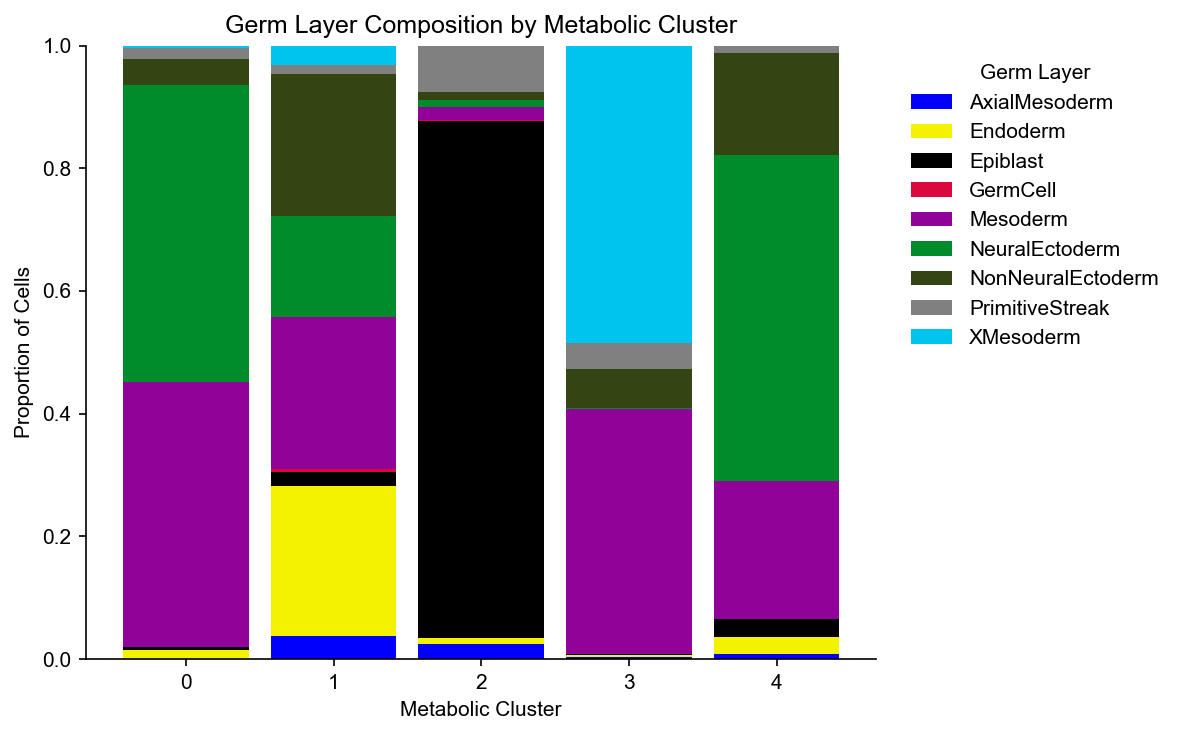

In [11]:
cluster_key = "met_leiden"
group_key = "germlayer"

rna.obs[cluster_key] = rna.obs[cluster_key].astype(str).astype("category")

counts = pd.crosstab(
    rna.obs[cluster_key],
    rna.obs[group_key],
)

props = counts.div(counts.sum(axis=1), axis=0)

germlayer_order = list(rna.obs[group_key].cat.categories)
props = props.reindex(columns=germlayer_order, fill_value=0)

colors = [
    GERMLAYER_PALETTE.get(germlayer, MISSING_COLOR)
    for germlayer in germlayer_order
]

ax = props.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(8, 5),
    width=0.85,
    edgecolor="none",
)

ax.set_xlabel("Metabolic Cluster")
ax.set_ylabel("Proportion of Cells")
ax.set_title("Germ Layer Composition by Metabolic Cluster")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Germ Layer",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

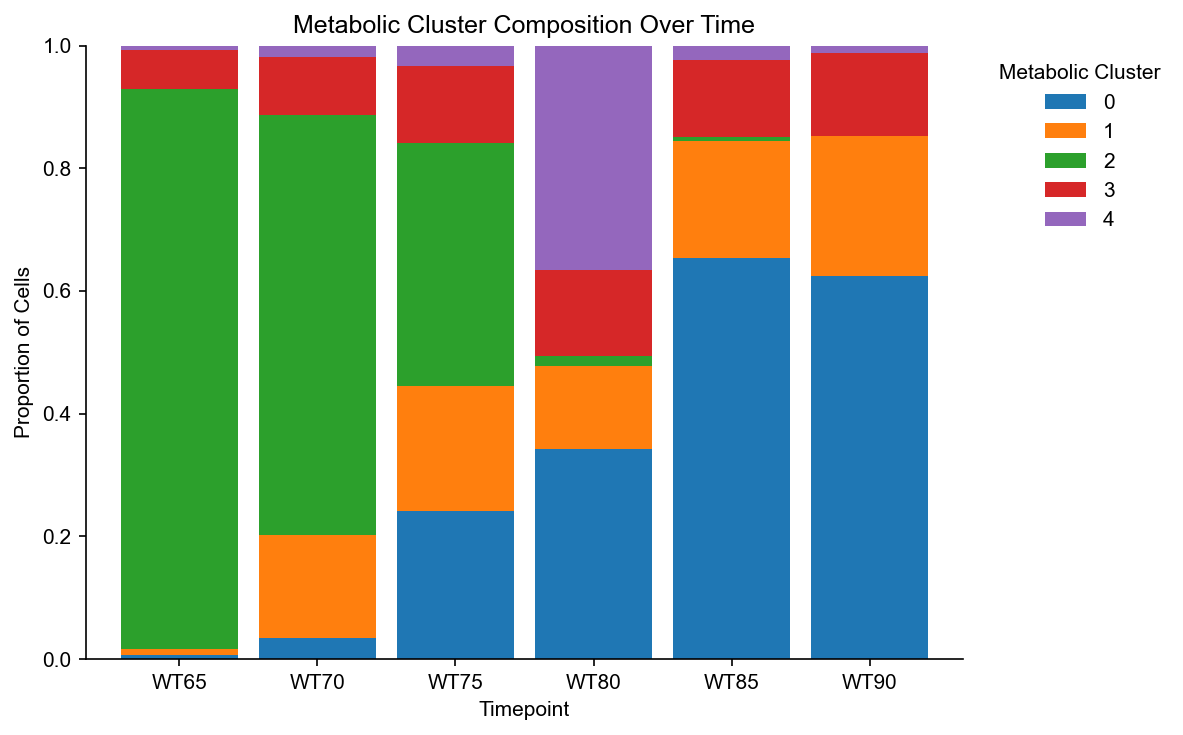

In [12]:
time_key = "timepoint"
cluster_key = "met_leiden"

rna.obs[time_key] = rna.obs[time_key].astype(str).astype("category")
rna.obs[cluster_key] = rna.obs[cluster_key].astype(str).astype("category")

counts = pd.crosstab(
    rna.obs[time_key],
    rna.obs[cluster_key],
)

props = counts.div(counts.sum(axis=1), axis=0)

cluster_order = sorted(
    rna.obs[cluster_key].cat.categories,
    key=lambda x: int(x) if str(x).isdigit() else str(x),
)

props = props.reindex(columns=cluster_order, fill_value=0)

cluster_palette = dict(
    zip(
        cluster_order,
        sns.color_palette("tab10", n_colors=len(cluster_order)).as_hex(),
    )
)

colors = [cluster_palette[c] for c in cluster_order]

ax = props.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(8, 5),
    width=0.85,
    edgecolor="none",
)

ax.set_xlabel("Timepoint")
ax.set_ylabel("Proportion of Cells")
ax.set_title("Metabolic Cluster Composition Over Time")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Metabolic Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

## Reaction Activity, KEGG Pathway, and DDP Calculations

MeRN decodes each cell into **reaction activity**: how active every metabolic reaction is inferred to be in that cell. From this reaction activity matrix we build two coarser summaries — canonical KEGG pathway scores, and data-driven pathways (DDPs) learned from the data itself.

That gives three activity matrices, at increasing levels of aggregation, which we use throughout the rest of the tutorial:

1. **Reaction activity**: cells × reactions
2. **KEGG pathway activity**: cells × canonical KEGG pathways
3. **DDP activity**: cells × data-driven pathways

Every later section presents these three in the same order, from the finest to the coarsest view.

A note on naming: the package calls this quantity *enzyme activity* in its function and variable names (`mern_support.average_enzyme_activity`, `enzyme_acts_mean`, and the `mern average-enzyme-activity` CLI command). It is the same matrix. This tutorial says **reaction activity** in the text and figures, because the values are indexed by reaction rather than by gene.

![DDPs](figures/ddps.png)

### Decoding Reaction Activity

MeRN decodes each cell into reaction-level activity: a cells x reactions matrix giving the
activity inferred for each reaction in each cell.

Decoding is stochastic, and separately trained replicates differ from one another, so the activity
used for analysis is averaged rather than taken from a single decode.
`mern_support.average_enzyme_activity` handles both: it decodes `n_samples` times per model and
averages across every replicate it is given.

To demonstrate, below we average one decode from each replicate over a subset of cells to keep the runtime short.

In [13]:
demo_cells = rna.obs_names[:2000]
demo = rna[demo_cells].copy()

demo_activity = mern_support.average_enzyme_activity(models, demo, n_samples=1, show_progress=False)

print(f'{demo_activity.shape[0]:,} cells x {demo_activity.shape[1]:,} reactions')
display(demo_activity.iloc[:4, :3])

Seed set to 8


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Seed set to 1008


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
2,000 cells x 1,213 reactions


,rn:R00351 rn:R00352,rn:R00209 rn:R00212 rn:R01196 rn:R10866,rn:R00341 rn:R00345 rn:R00346 rn:R00431 rn:R00726
WT65_1_CTCCCAATCATCAGTG-1,1.352603,3.420457,1.728265
WT65_1_TCTAACTGTCATCACA-1,1.471367,5.341058,3.156581
WT65_1_AGCATCACACTGCACG-1,1.156132,2.768928,1.897655
WT65_1_AAGAACAAGAATCGCG-1,1.718117,4.129530,3.405230


The enzyme activity used for the rest of this tutorial follows the paper: **8 decodes for each of the 10
replicates**, over all cells. That is 80 decodes, so it is provided precomputed rather than run here.

```python
mern_support.average_enzyme_activity(models, rna, n_samples=8)
```

In [14]:
enzyme_acts_mean = pd.read_csv(f'{base_path_model}/average_enzyme_activity.csv.gz', index_col=0)

assert enzyme_acts_mean.index.equals(rna.obs_names)
assert enzyme_acts_mean.columns.equals(demo_activity.columns)

print(f'{enzyme_acts_mean.shape[0]:,} cells x {enzyme_acts_mean.shape[1]:,} reactions')

6,000 cells x 1,213 reactions


### Calculating KEGG Pathway Scores

The first summary of reaction activity is the canonical one: KEGG's own pathway definitions.

The input reaction activity matrix contains cells as rows and metabolic reactions as columns. Using the reaction metadata in `rxn_info`, each reaction is mapped to one or more KEGG pathways. For each cell and each KEGG pathway, we calculate the average reaction activity over the reactions assigned to that pathway.

This produces three outputs:

- `pathway_scores`: a cells × KEGG pathways matrix of pathway activity scores
- `pathway_rxns`: a dictionary mapping each KEGG pathway ID to its member reactions
- `pathway_names`: a dictionary mapping KEGG pathway IDs to readable pathway names

These pathway scores give a canonical pathway-level view of metabolic activity. Because the pathway boundaries are drawn in advance, they are broad and identical for every dataset, which is what motivates the data-driven alternative in the next section.

In [15]:
pathway_scores, pathway_rxns, pathway_names = mern_support.calculate_pathway_scores(
    enzyme_acts=enzyme_acts_mean,
    reaction_info=rxn_info
)

print("\nKEGG pathway activity matrix")
print("  cells x pathways:", pathway_scores.shape)

pathway_sizes = pd.Series(
    {pathway: len(rxns) for pathway, rxns in pathway_rxns.items() if pathway in pathway_scores.columns},
    name="n_reactions",
)

display(pathway_sizes.describe())
display(pathway_scores.head())



KEGG pathway activity matrix
  cells x pathways: (6000, 122)


count     122.000000
mean       30.229508
std       112.081197
min         1.000000
25%         4.000000
50%        14.000000
75%        27.000000
max      1213.000000
Name: n_reactions, dtype: float64

,rn00020,rn00630,rn01100,rn01110,rn01120,rn01200,rn01210,rn01230,rn00720,rn00620,...,rn00604,rn00625,rn00930,rn00740,rn00750,rn00830,rn00232,rn00660,rn00524,rn00531
WT65_1_CTCCCAATCATCAGTG-1,0.951912,1.857626,0.922668,1.299728,1.347413,1.857107,1.094448,2.565384,0.926988,1.230659,...,0.146055,0.70530,0.09305,1.588867,0.409850,0.248233,0.213000,0.3476,0.2116,0.306972
WT65_1_TCTAACTGTCATCACA-1,1.224647,2.077930,0.974335,1.328220,1.504209,2.096121,1.243705,2.682230,1.192115,1.535515,...,0.152090,0.72645,0.12705,1.695833,0.485275,0.202150,0.158475,0.3588,0.5612,0.298561
WT65_1_AGCATCACACTGCACG-1,1.010524,1.786170,1.001531,1.436797,1.498098,2.047824,1.171033,2.791532,0.961912,1.425437,...,0.189940,0.75895,0.11010,1.630367,0.486337,0.291150,0.251050,0.3188,0.4710,0.287422
WT65_1_AAGAACAAGAATCGCG-1,1.545759,2.031493,1.023243,1.474702,1.668811,2.236064,1.446648,3.028289,1.374344,1.895993,...,0.203490,0.80055,0.15695,1.561500,0.452400,0.314933,0.353825,0.3208,0.6015,0.291933
WT65_1_AGACAAATCCAACCGG-1,1.670500,2.453307,1.153472,1.690726,1.937548,2.727053,1.598252,3.259156,1.728926,2.181537,...,0.138455,0.81175,0.12510,1.546833,0.327650,0.361933,0.411900,0.4549,0.3680,0.382222


### Calculating Data-Driven Pathways (DDPs)

KEGG pathways are defined in advance and are the same for every dataset. DDPs are the data-driven counterpart: groups of reactions that are both connected in the metabolic reaction graph and coordinated across the cells of *this* dataset.

To construct DDPs, we:

1. Restrict to reactions present in both the reaction activity matrix and the metabolic graph.
2. Remove reactions with no variation across cells.
3. Compute reaction-reaction correlations across cells.
4. Cluster graph-connected reactions using a minimum correlation threshold.
5. Score each cell for each DDP by averaging reaction activity across member reactions.

The resulting `ddp_scores` matrix has cells as rows and DDPs as columns.

In [16]:
ddp_min_corr = 0.7
ddp_min_size = 3

common_rxns = enzyme_acts_mean.columns.intersection(pd.Index(met_g.nodes()))

enzyme_acts_ddp = enzyme_acts_mean.loc[:, common_rxns].copy()

enzyme_acts_ddp = enzyme_acts_ddp.loc[:, enzyme_acts_ddp.std(axis=0) > 0].copy()

print("\nDDP construction input")
print("  cells x graph reactions:", enzyme_acts_ddp.shape)

corr_df = enzyme_acts_ddp.corr()

rxn_to_ddp, ddp_rxns, ddp_clusters, _ = mern_support.calculate_ddps(
    G=met_g,
    corr_df=corr_df,
    min_corr=ddp_min_corr,
    min_size=ddp_min_size,
)

print("\nDDPs")
print("  number of DDPs:", len(ddp_rxns))

ddp_sizes = pd.Series(
    {ddp: len(rxns) for ddp, rxns in ddp_rxns.items()},
    name="n_reactions",
)

display(ddp_sizes.describe())
display(ddp_sizes.sort_values(ascending=False).head(10))

ddp_scores, ddp_rxns = mern_support.calculate_ddp_scores(
    enzyme_acts=enzyme_acts_ddp,
    rxn_to_ddp=rxn_to_ddp,
)

print("\nDDP activity matrix")
print("  cells x DDPs:", ddp_scores.shape)


DDP construction input
  cells x graph reactions: (6000, 1213)

DDPs
  number of DDPs: 112


count    112.000000
mean      10.053571
std        9.569885
min        3.000000
25%        4.000000
50%        7.000000
75%       13.000000
max       49.000000
Name: n_reactions, dtype: float64

ddp_111    49
ddp_110    46
ddp_109    39
ddp_108    39
ddp_107    37
ddp_106    37
ddp_105    33
ddp_104    24
ddp_103    24
ddp_102    23
Name: n_reactions, dtype: int64


DDP activity matrix
  cells x DDPs: (6000, 112)


## Metabolic Activity Summaries Across Clusters

We next summarize MeRN-derived metabolic activity across the metabolic clusters identified from the metabolic embedding.

We compare three levels of metabolic organization, in the same order as the previous section:

1. **Reaction activity**: individual MeRN-inferred reaction activities
2. **KEGG pathway activity**: canonical pathway-level summaries
3. **DDP activity**: data-driven metabolic programs built from coordinated graph-connected reactions

For each matrix, we average activity within each metabolic cluster and standardize each feature across clusters. This highlights features that are relatively higher or lower in specific metabolic states.

### Reaction-Level Activity Across Metabolic Clusters

We first visualize reaction-level activity. Each row is a metabolic reaction and each column is a metabolic cluster. Values are average reaction activity within each cluster, z-scored across clusters.

Because there are many reactions, we show the top variable reactions across clusters. This gives a high-resolution view of which individual reactions distinguish metabolic states.

calling out 13 of the 200 reactions shown


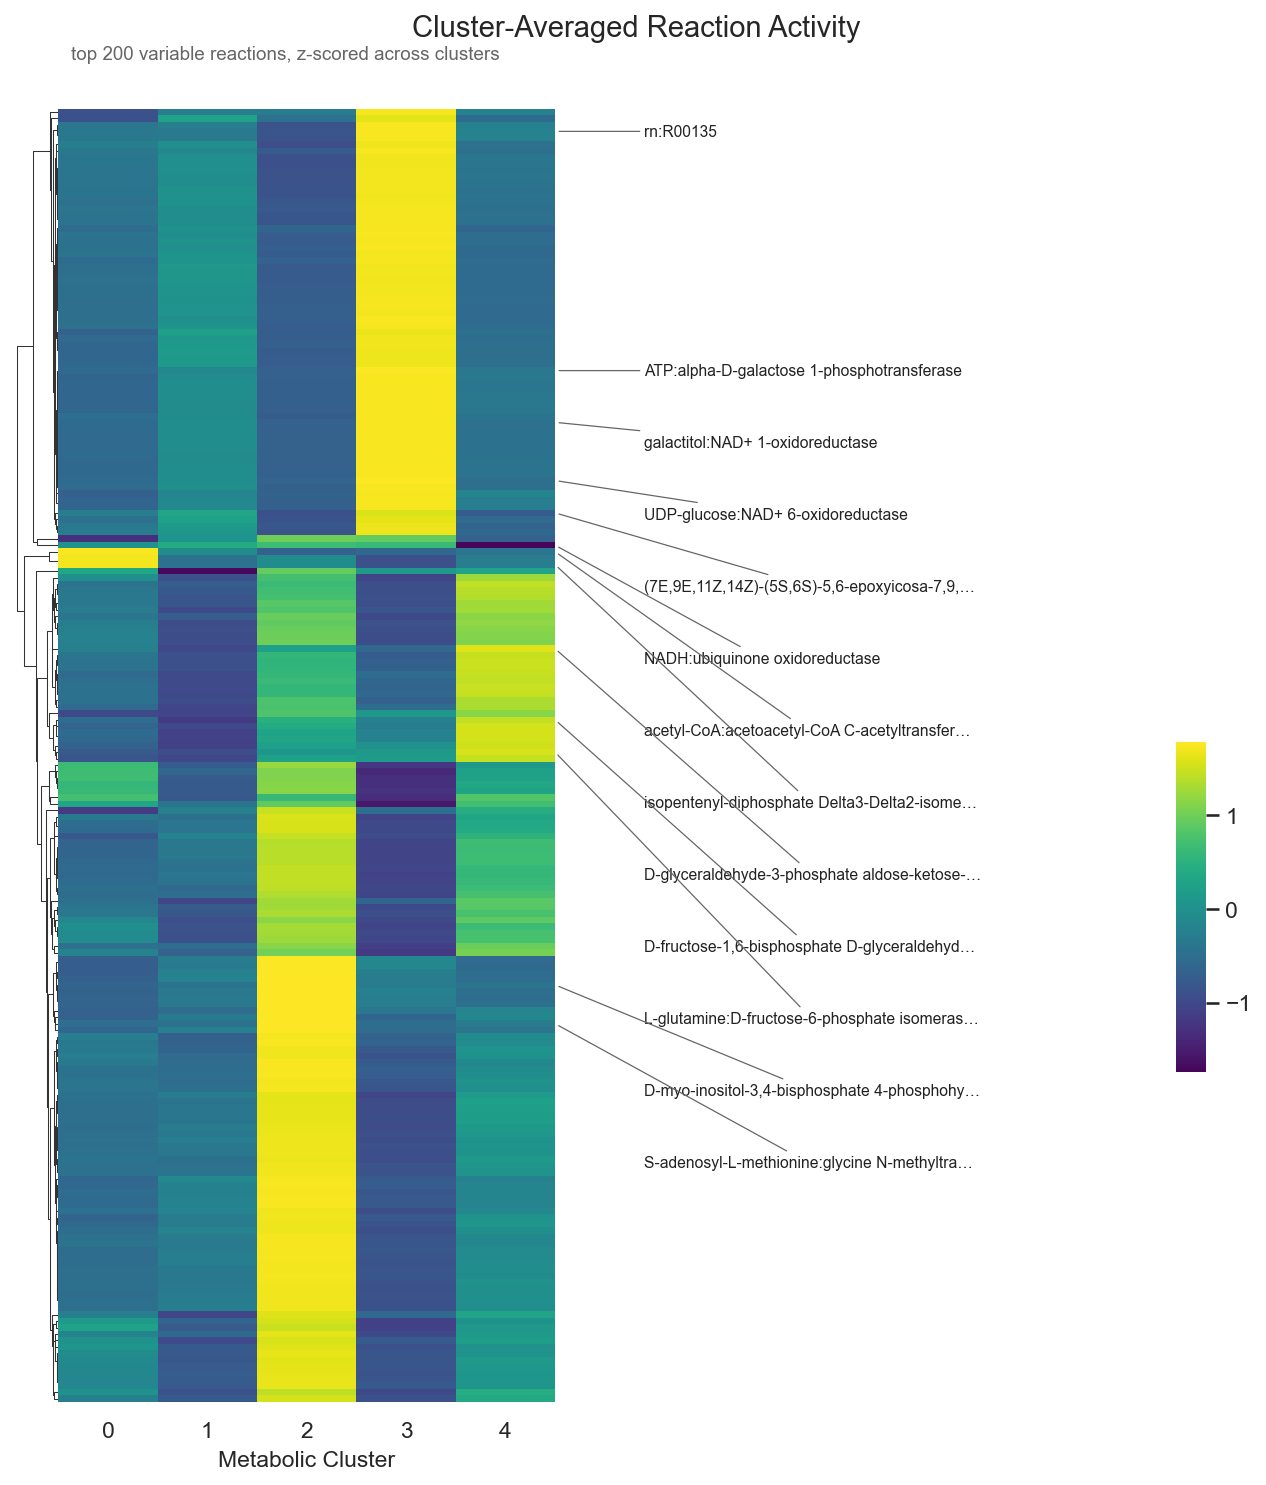

In [17]:
styled_theme(style="white", font_scale=1.0)

cluster_key = "met_leiden"
cluster_series = rna.obs[cluster_key].astype(str)

cluster_means = enzyme_acts_mean.groupby(cluster_series, observed=False).mean().T
cluster_means = cluster_means.loc[cluster_means.std(axis=1) > 0].copy()

top_n_rxns = 200
top_rxns = (
    cluster_means.var(axis=1)
    .sort_values(ascending=False)
    .head(top_n_rxns)
    .index
)

cluster_means = cluster_means.loc[top_rxns]

plot_data = cluster_means.sub(cluster_means.mean(axis=1), axis=0)
plot_data = plot_data.div(cluster_means.std(axis=1), axis=0)
plot_data.index = plot_data.index.astype(str)


def rxn_display_name(rxn_id, max_chars=44):
    """A readable name for a reaction node.

    `Rxn Name` holds the KEGG enzyme name of every reaction in the node, joined by ';' where a
    node groups several; the first is enough to identify the chemistry on a figure.
    """
    raw = str(rxn_info['Rxn Name'].get(rxn_id, '')).split(';')[0].strip()
    if not raw:
        raw = rxn_id
    return raw if len(raw) <= max_chars else raw[:max_chars - 1] + '…'


# Labelling all 200 rows is unreadable, so call out a defined selection instead of none: the two
# most cluster-specific reactions per metabolic cluster, plus the most variable reactions overall.
n_per_cluster = 2
n_overall = 4
callout_rxns = []
for cluster in plot_data.columns:
    callout_rxns += (
        plot_data[cluster].sort_values(ascending=False).head(n_per_cluster).index.tolist()
    )
callout_rxns += plot_data.var(axis=1).sort_values(ascending=False).head(n_overall).index.tolist()
callout_rxns = list(dict.fromkeys(callout_rxns))
print(f'calling out {len(callout_rxns)} of the {len(plot_data)} reactions shown')

g = sns.clustermap(
    plot_data,
    cmap=HEATMAP_CMAP,
    center=0,
    row_cluster=True,
    col_cluster=False,
    xticklabels=True,
    yticklabels=False,
    figsize=(9, 10),
    dendrogram_ratio=(0.08, 0.02),
    cbar_pos=(0.90, 0.28, 0.022, 0.22),
)

g.ax_heatmap.set_xlabel("Metabolic Cluster", fontsize=11)
# The clustermap puts the y axis on the right, where the callouts go, so the row count moves
# into the title rather than colliding with the labels.
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.tick_params(axis="x", rotation=0)

g.fig.suptitle("Cluster-Averaged Reaction Activity", fontsize=14, y=0.985)
g.fig.text(
    0.24, 0.955, f"top {top_n_rxns} variable reactions, z-scored across clusters",
    ha="center", fontsize=9, color=STRUCTURE_COLOR,
)
g.fig.subplots_adjust(left=0.04, right=0.44, top=0.94, bottom=0.06)
g.cax.set_position([0.90, 0.28, 0.022, 0.22])

# Clustering reorders the rows, so a callout has to be placed at its position in the drawn order.
n_rows, n_cols = plot_data.shape
row_order = list(g.dendrogram_row.reordered_ind)
display_pos = {plot_data.index[original]: drawn for drawn, original in enumerate(row_order)}

points = sorted((display_pos[rxn] + 0.5, rxn) for rxn in callout_rxns)

# Spread the labels vertically so they do not overlap, then pull them back inside the axis.
min_gap = n_rows / (len(points) + 1) * 0.78
label_y = []
for y, _ in points:
    label_y.append(y if not label_y else max(y, label_y[-1] + min_gap))
overflow = label_y[-1] - (n_rows - 0.5)
if overflow > 0:
    label_y = [y - overflow for y in label_y]

for (row_y, rxn), text_y in zip(points, label_y):
    g.ax_heatmap.annotate(
        rxn_display_name(rxn),
        xy=(n_cols, row_y),
        xytext=(n_cols + 0.9, text_y),
        textcoords="data",
        fontsize=7.5,
        va="center",
        ha="left",
        color=TEXT_COLOR,
        arrowprops=dict(
            arrowstyle="-",
            color=STRUCTURE_COLOR,
            linewidth=0.6,
            shrinkA=0,
            shrinkB=2,
        ),
        annotation_clip=False,
    )

plt.show()

### KEGG Pathway Activity Across Metabolic Clusters

Next, we aggregate reaction activity into KEGG pathway scores. Each row is a KEGG pathway and each column is a metabolic cluster. Values are average pathway activity within each cluster, z-scored across clusters.

This provides a canonical pathway-level summary of metabolic differences between clusters.

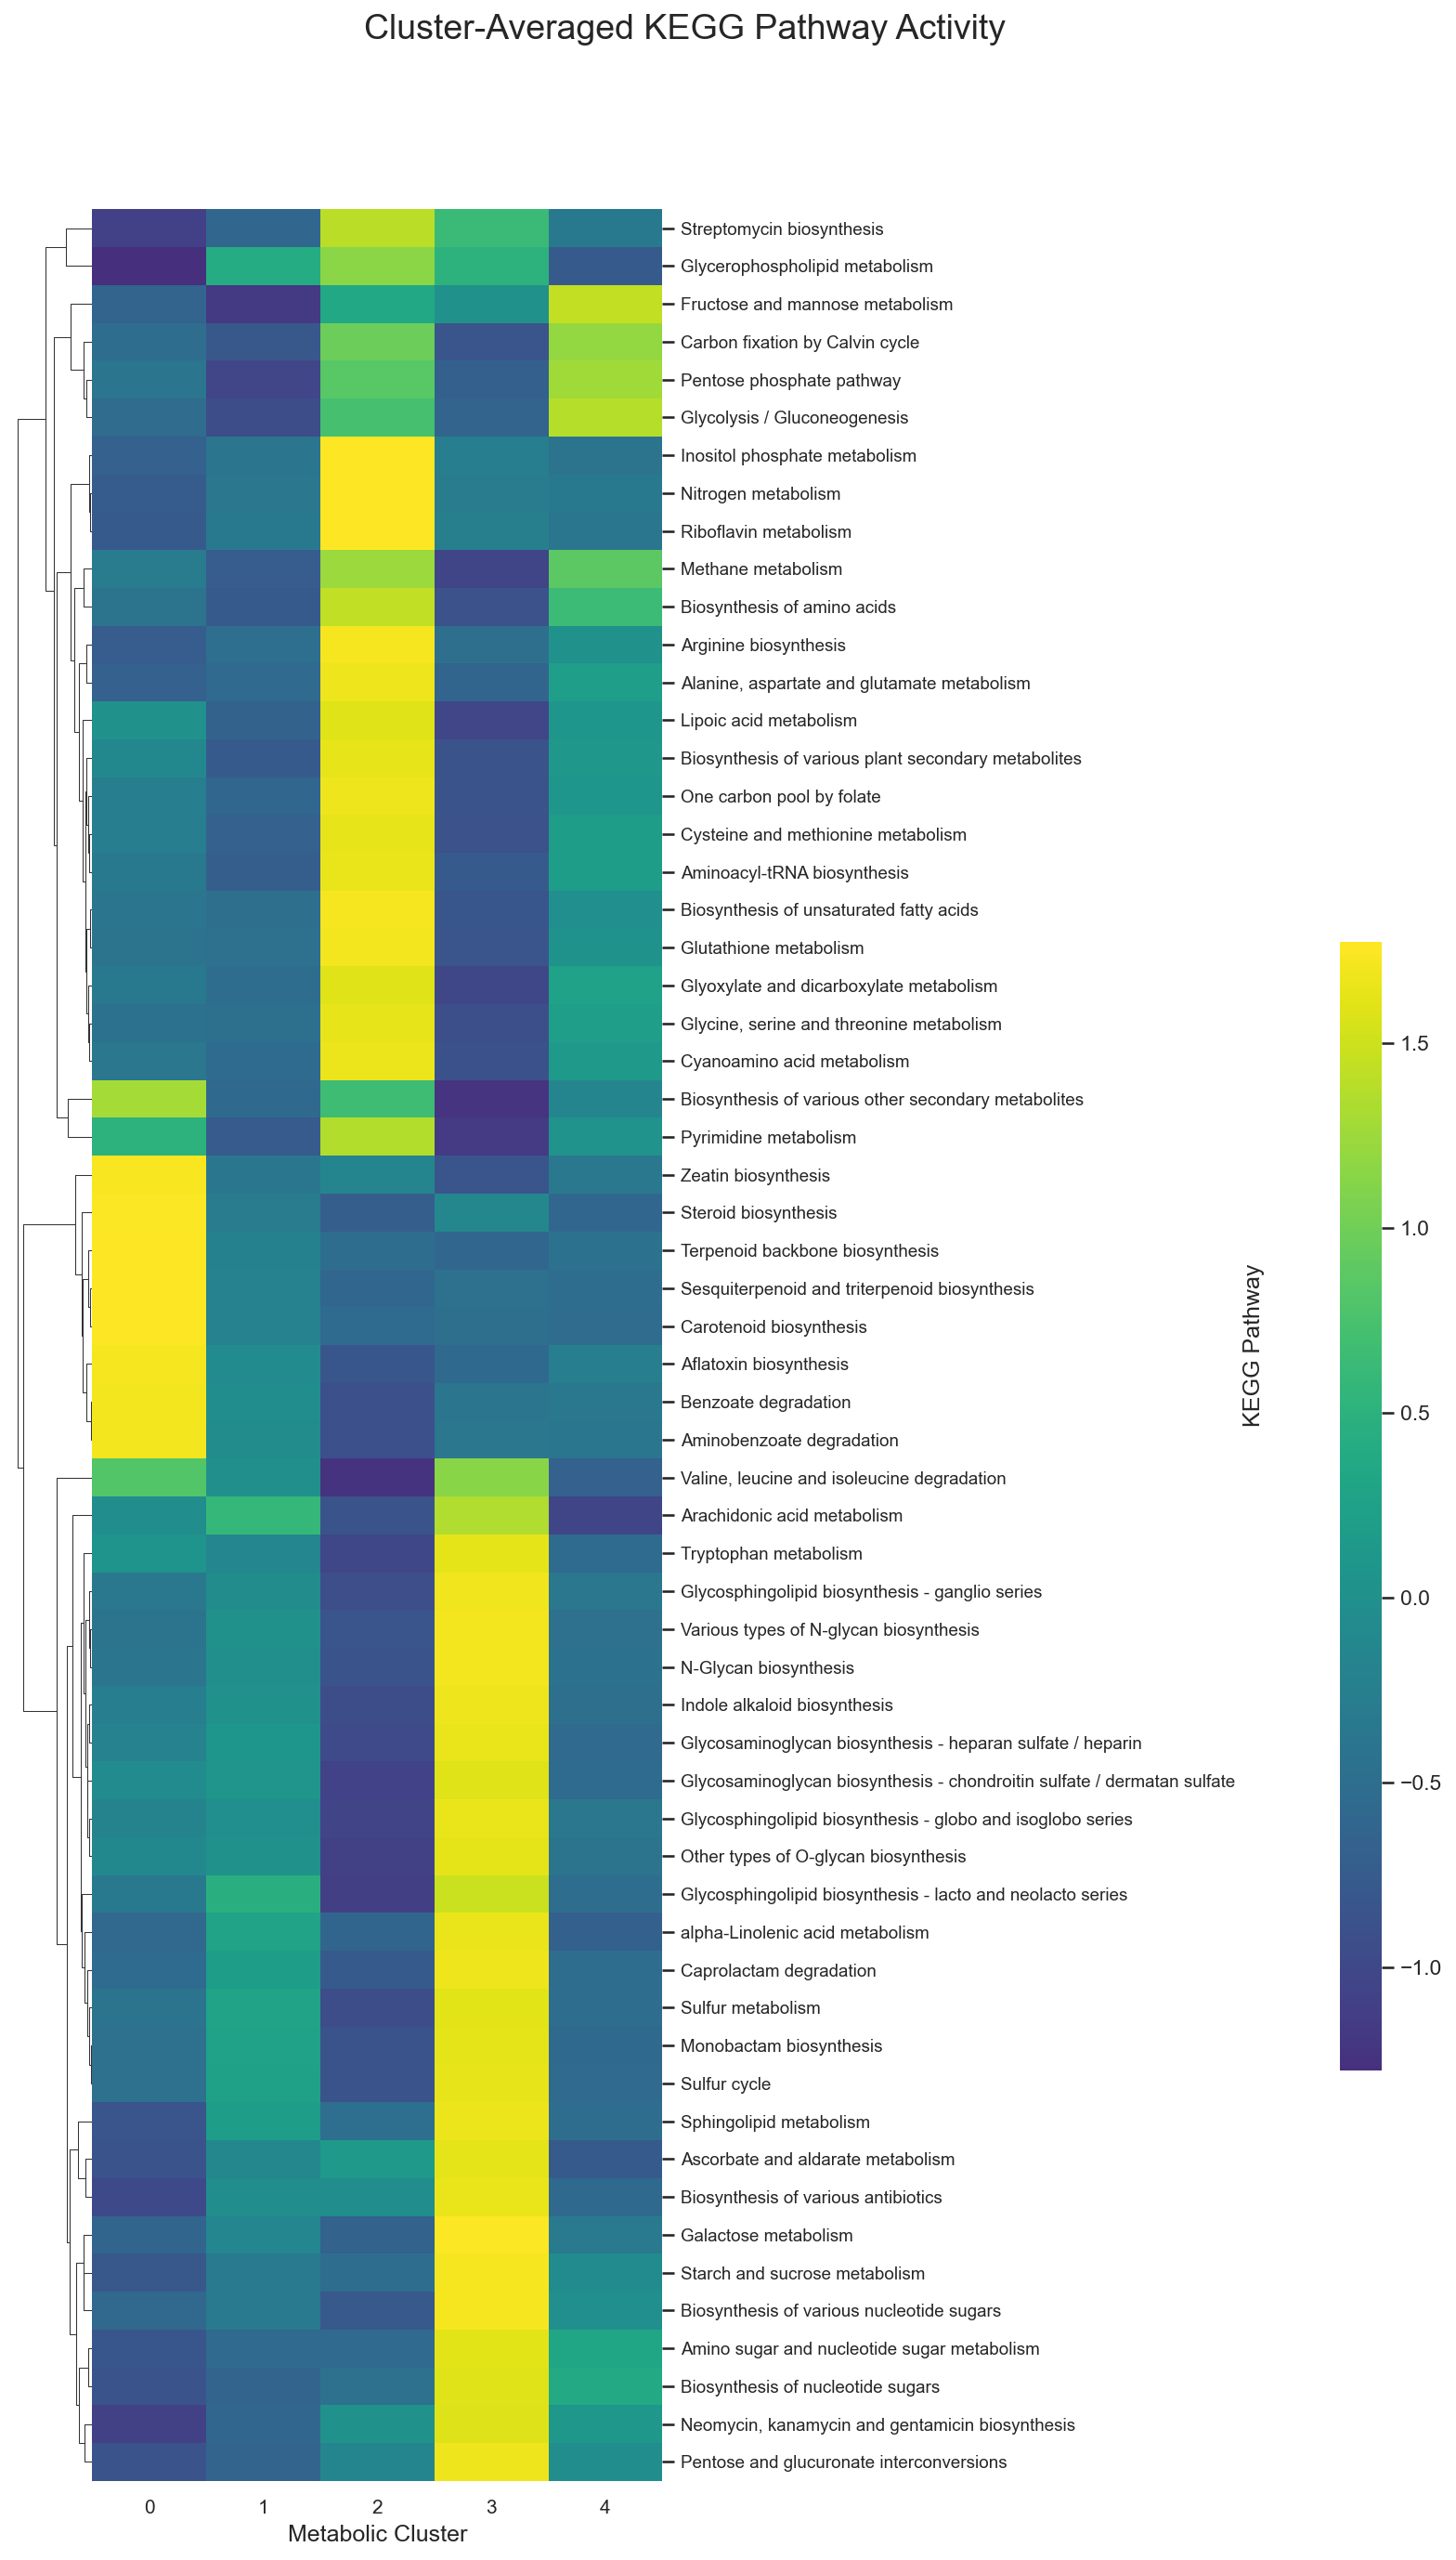

In [18]:
styled_theme(style="white", font_scale=1.0)

cluster_key = "met_leiden"
cluster_series = rna.obs[cluster_key].astype(str)

pathway_cluster_means = pathway_scores.groupby(cluster_series, observed=False).mean().T

exclude_pathways = {"rn01100", "rn01110", "rn01120", "rn01200"}

pathway_cluster_means = pathway_cluster_means.loc[
    ~pathway_cluster_means.index.isin(exclude_pathways)
].copy()

pathway_cluster_means = pathway_cluster_means.loc[
    pathway_cluster_means.std(axis=1) > 0
].copy()

top_n_pathways = 60

top_pathways = (
    pathway_cluster_means.var(axis=1)
    .sort_values(ascending=False)
    .head(top_n_pathways)
    .index
)

pathway_cluster_means = pathway_cluster_means.loc[top_pathways]

plot_data = pathway_cluster_means.sub(pathway_cluster_means.mean(axis=1), axis=0)
plot_data = plot_data.div(pathway_cluster_means.std(axis=1), axis=0)

plot_data.index = [pathway_names.get(pid, pid) for pid in plot_data.index]

g = sns.clustermap(
    plot_data,
    cmap=HEATMAP_CMAP,
    center=0,
    row_cluster=True,
    col_cluster=False,
    xticklabels=True,
    yticklabels=True,
    figsize=(10, 18),
    dendrogram_ratio=(0.12, 0.05),
    cbar_pos=(0.97, 0.2, 0.03, 0.45),
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=0, fontsize=10)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)

g.ax_heatmap.set_xlabel("Metabolic Cluster", fontsize=12)
g.ax_heatmap.set_ylabel("KEGG Pathway", fontsize=12)
g.fig.suptitle("Cluster-Averaged KEGG Pathway Activity", fontsize=18, y=1.02)

plt.show()


### DDP Activity Across Metabolic Clusters

Finally, we summarize activity at the DDP level. Each row is a data-driven pathway and each column is a metabolic cluster. Values are average DDP activity within each cluster, z-scored across clusters.

DDPs provide an intermediate view between individual reactions and broad KEGG pathways as they group reactions that are connected in the metabolic graph and coordinated across cells.

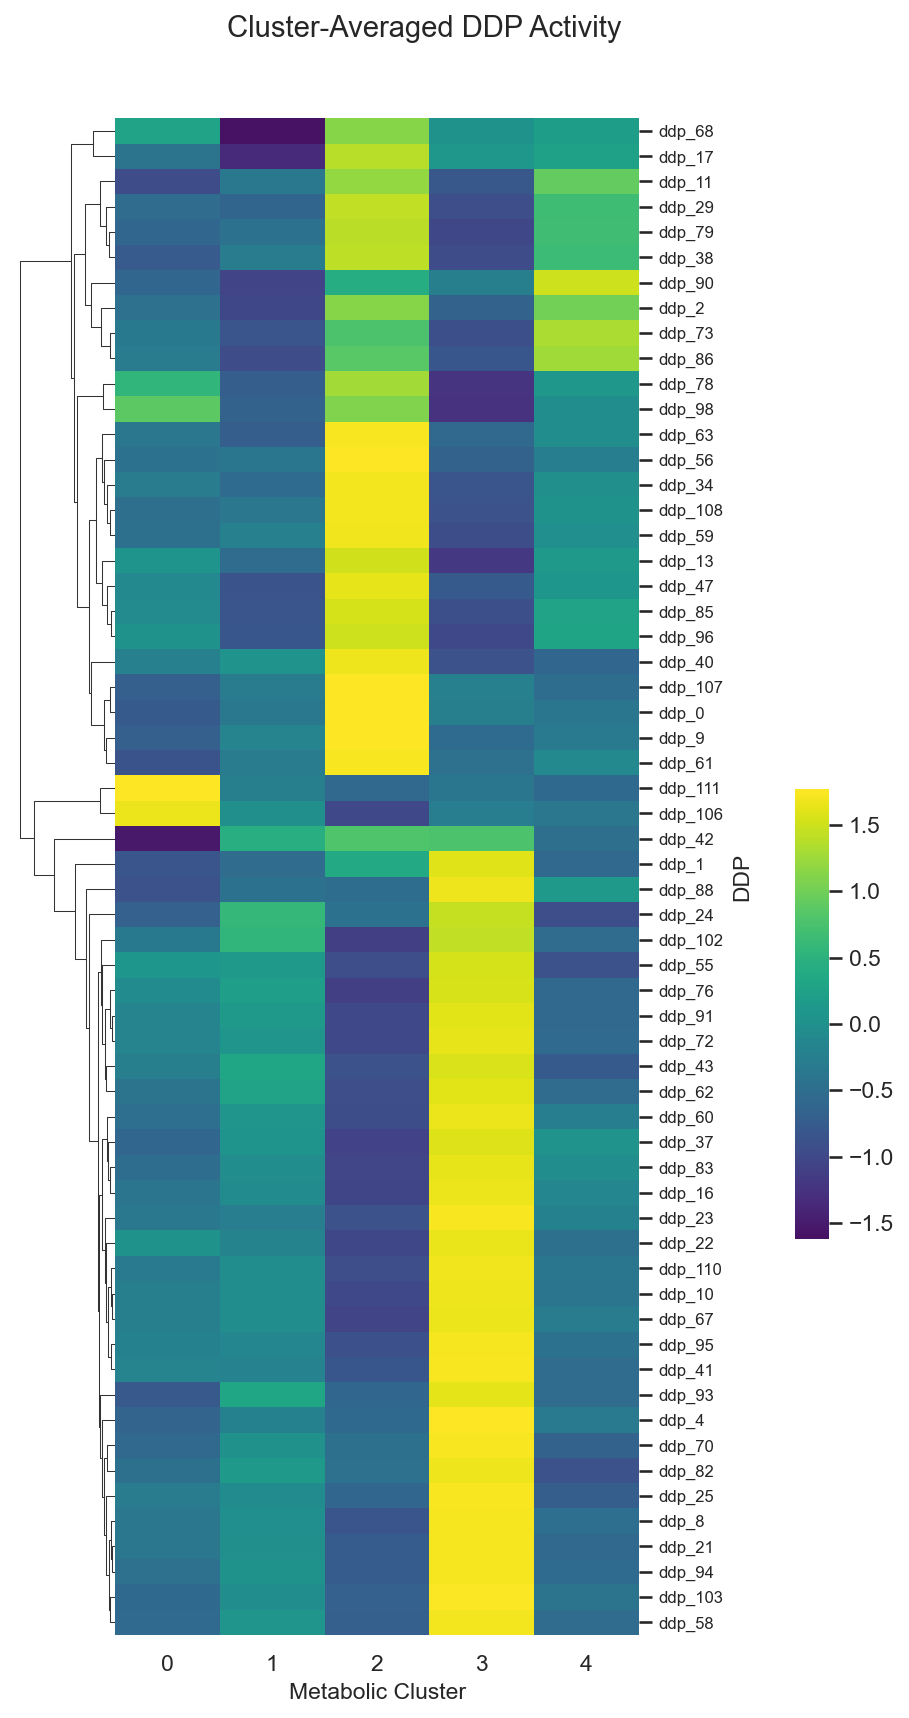

In [19]:
styled_theme(style="white", font_scale=1.0)

cluster_key = "met_leiden"
cluster_series = rna.obs[cluster_key].astype(str)

ddp_cluster_means = ddp_scores.groupby(cluster_series, observed=False).mean().T

ddp_cluster_means = ddp_cluster_means.loc[
    ddp_cluster_means.std(axis=1) > 0
].copy()

top_n_ddps = 60

top_ddps = (
    ddp_cluster_means.var(axis=1)
    .sort_values(ascending=False)
    .head(top_n_ddps)
    .index
)

ddp_cluster_means = ddp_cluster_means.loc[top_ddps]

plot_data = ddp_cluster_means.sub(ddp_cluster_means.mean(axis=1), axis=0)
plot_data = plot_data.div(ddp_cluster_means.std(axis=1), axis=0)

plot_data.index = plot_data.index.astype(str)

g = sns.clustermap(
    plot_data,
    cmap=HEATMAP_CMAP,
    center=0,
    row_cluster=True,
    col_cluster=False,
    xticklabels=True,
    yticklabels=True,
    figsize=(6.5, 12),
    dendrogram_ratio=(0.16, 0.02)
)

g.ax_heatmap.set_xlabel("Metabolic Cluster", fontsize=11)
g.ax_heatmap.set_ylabel("DDP", fontsize=11)
g.ax_heatmap.tick_params(axis="x", rotation=0)
g.ax_heatmap.tick_params(axis="y", labelsize=8)

g.fig.suptitle("Cluster-Averaged DDP Activity", fontsize=14, y=0.98)

g.fig.subplots_adjust(left=0.08, right=0.72, top=0.94, bottom=0.08)
g.cax.set_position([0.88, 0.30, 0.035, 0.25])

plt.show()


## Visualizing Metabolic Programs on KEGG Pathway Graphs

After summarizing reaction, KEGG pathway, and DDP activity across metabolic clusters, we can project these signals back onto metabolic pathway structure. This helps connect the matrix-level summaries to specific reactions and metabolites within known biochemical pathways.

Here we use glycolysis/gluconeogenesis as an example pathway.

### Glycolysis Reactions Colored by DDP Membership

In this plot, each edge represents a reaction in the [KEGG glycolysis/gluconeogenesis pathway (rn00010)](https://www.kegg.jp/pathway/rn00010). We color each reaction by the DDP it belongs to.

In [20]:

pathway_id_to_plot = "rn00010"

ddp_edge_labels = rxn_to_ddp.copy()

with ddp_pathway_palette(ddp_edge_labels):
    fig = mern_support.kegg_pathway_plot(
        pathway=pathway_id_to_plot,
        dataset=dataset,
        rna=rna,
        user_labels=ddp_edge_labels,
        edge_width=4,
        show_node_labels=True,
        labeled_nodes=metabolite_labels(dataset, pathway=pathway_id_to_plot),
    )

fig.update_layout(
    title="Glycolysis / Gluconeogenesis: Reactions Colored by DDP Membership"
)

fig.write_image(f"{base_path_figures}/glycolysis_ddp_plot.png", width=1200, height=800, scale=2)
fig.show()


![Glycolysis DDP plot](figures/glycolysis_ddp_plot.png)

### Glycolysis Reactions Colored by Differential Activity

We next color the glycolysis pathway by reaction-level differential activity between two metabolic
clusters. Leiden numbers its clusters in an order that depends on the cells present, so instead of
naming two ids this cell picks the contrast the figure is meant to show: the metabolic cluster with
the highest mean glycolysis activity against the one with the lowest, among clusters large enough
for the test to mean anything.

For each reaction, we compare inferred reaction activity between those two clusters using a
Wilcoxon rank-sum test. The edge color shows Cohen’s d effect size:

- positive values indicate higher inferred reaction activity in the high-glycolysis cluster
- negative values indicate higher inferred reaction activity in the low-glycolysis cluster

In [21]:
pathway_id_to_plot = "rn00010"

cluster_key = "met_leiden"
cluster_labels = rna.obs[cluster_key].astype(str)

# Leiden renumbers on any change to the cell set, so the two clusters are chosen by the contrast
# this figure exists to show rather than by id: highest against lowest mean glycolysis activity,
# among clusters with enough cells for the rank-sum test to be meaningful.
min_cluster_cells = 100
assert pathway_id_to_plot in pathway_scores.columns, 'glycolysis is not in the pathway scores'

cluster_sizes = cluster_labels.value_counts()
eligible = cluster_sizes.index[cluster_sizes >= min_cluster_cells]
glycolysis_by_cluster = (
    pathway_scores[pathway_id_to_plot]
    .groupby(cluster_labels, observed=False)
    .mean()
    .reindex(eligible)
    .dropna()
)
up_cluster = str(glycolysis_by_cluster.idxmax())
down_cluster = str(glycolysis_by_cluster.idxmin())
print(f'cluster {up_cluster} (highest mean glycolysis activity) vs '
      f'cluster {down_cluster} (lowest), of {len(eligible)} clusters with '
      f'at least {min_cluster_cells} cells')

up_cells = rna.obs_names[cluster_labels == up_cluster]
down_cells = rna.obs_names[cluster_labels == down_cluster]

rxn_de = mern_support.wilcoxon_test(
    enzyme_acts_mean.T,
    up_cells,
    down_cells,
)

rxn_de_info = rxn_info.join(rxn_de)

edge_color_limits = (-2, 2)

edge_values = (
    rxn_de_info["cohens_d"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .clip(lower=edge_color_limits[0], upper=edge_color_limits[1])
)

fig = mern_support.kegg_pathway_plot(
    pathway=pathway_id_to_plot,
    dataset=dataset,
    rna=rna,
    user_labels=edge_values,
    edge_width=4,
    edge_color_limits=edge_color_limits,
    color_scale="RdBu_r",
    show_node_labels=True,
    labeled_nodes=metabolite_labels(dataset, pathway=pathway_id_to_plot),
)

fig.update_layout(
    title=(
        f"Glycolysis / Gluconeogenesis: Reaction Activity "
        f"Cluster {up_cluster} vs Cluster {down_cluster}"
    )
)

fig.write_image(f"{base_path_figures}/glycolysis_cohensd_plot.png", width=1200, height=800, scale=2)
fig.show()

cluster 4 (highest mean glycolysis activity) vs cluster 1 (lowest), of 5 clusters with at least 100 cells


![Glycolysis Cohen's D plot](figures/glycolysis_cohensd_plot.png)

### Identifying DDPs Connected to Glycolysis

A KEGG pathway shows reactions within a canonical pathway boundary. DDPs can extend this view by linking pathway reactions to other reactions that are coordinated with them across cells.

Here we identify all DDPs that contain at least one reaction annotated to glycolysis/gluconeogenesis. In the next plot, we expand beyond the KEGG glycolysis pathway by including all reactions from those glycolysis-associated DDPs.

In [22]:

pathway_id_to_plot = "rn00010"

glycolysis_rxns = set(pathway_rxns[pathway_id_to_plot])

glycolysis_ddps = sorted(
    rxn_to_ddp.loc[
        rxn_to_ddp.index.intersection(glycolysis_rxns)
    ]
    .dropna()
    .unique(),
    key=lambda x: int(str(x).split("_")[-1]) if str(x).split("_")[-1].isdigit() else str(x),
)

print("Glycolysis-associated DDPs:", glycolysis_ddps)


Glycolysis-associated DDPs: ['ddp_15', 'ddp_73', 'ddp_79', 'ddp_88', 'ddp_90', 'ddp_103', 'ddp_106']


In [23]:
expanded_rxns = sorted(
    set().union(*[set(ddp_rxns[ddp]) for ddp in glycolysis_ddps])
)

print("Glycolysis reactions:", len(glycolysis_rxns))
print("Expanded DDP reactions:", len(expanded_rxns))

Glycolysis reactions: 23
Expanded DDP reactions: 114


In [24]:
ddp_edge_labels = rxn_to_ddp.reindex(expanded_rxns)

expanded_labels = metabolite_labels(dataset, rxns=expanded_rxns, require_anchors=False)
print('labelled metabolites:', [dataset.compound_info[c.split('cpd:')[1]]['name'].split(';')[0]
                               for c in expanded_labels])

with ddp_pathway_palette(ddp_edge_labels):
    fig = mern_support.custom_pathway_plot(
        rxns=expanded_rxns,
        dataset=dataset,
        rna=rna,
        user_labels=ddp_edge_labels,
        edge_width=4,
        ddp_labels=rxn_to_ddp,
        ddp_color_map=ddp_color_map_for(ddp_edge_labels),
        ddp_style="soft_contours",
        show_node_labels=True,
        labeled_nodes=expanded_labels,
    )

fig.update_layout(
    title="Expanded Glycolysis-Associated DDP Network"
)

fig.write_image(f"{base_path_figures}/glycolysis_ddp_expanded_plot.png", width=1200, height=800, scale=2)
fig.show()


labelled metabolites: ['alpha-D-Glucose', 'D-Glucose', 'alpha-D-Glucose 6-phosphate', 'D-Fructose 6-phosphate', 'D-Fructose 1,6-bisphosphate', 'Glycerone phosphate', 'D-Glyceraldehyde 3-phosphate', '3-Phospho-D-glyceroyl phosphate', '3-Phospho-D-glycerate', '2-Phospho-D-glycerate', 'Phosphoenolpyruvate', 'Pyruvate', '(S)-Lactate']


![Glycolysis DDP Expanded plot](figures/glycolysis_ddp_expanded_plot.png)

## Comparing Metabolic Coordination in a *Folr1* Knockout

Everything above describes wild-type (WT) embryogenesis. We now bring in a second dataset: embryos
carrying a *Folr1* knockout, which severely restricts the embryo's ability to capture dietary folate.

The metabolic clustering of this dataset resolves six metabolic states, one of which (state 5) is
almost entirely depleted in the knockout. A whole-dataset comparison would therefore be dominated by
that shift in composition, so we compare a *single* metabolic state across genotypes instead.

Within a matched state, the interesting question is not only *which reactions change in mean
activity*, but *which reactions stop moving together*. A DDP is defined by coordination, so a
perturbation can leave average activity almost untouched while breaking the correlation structure
that held a DDP together. The weakest-link analysis is the tool for that comparison, applied here
across genotypes rather than across metabolic clusters.

The comparison needs three components:

1. **A shared cell population.** WT and *Folr1* cells were mapped onto the same reference metabolic
   clustering (`Metabolic Clustering Mapped`), so we can compare the *same* metabolic state across
   genotypes instead of comparing whole datasets.
2. **Replicate-averaged reaction activity for each genotype**, decoded from its own MeRN
   replicates with the analysis behind the paper's Figure 3.
3. **One metabolic graph.** We reuse the WT reaction graph `met_g` built earlier so both genotypes are
   clustered over identical connectivity, and only the correlations differ.

### Loading Reaction Activity for Both Genotypes

Each genotype's reaction activity is the replicate ensemble of the models trained on that genotype:
the wild-type table for WT cells and the *Folr1* table for knockout cells. Following the paper's
Methods, each is the ensemble mean over 8 Monte Carlo decodes for each of the 10 replicates.

In [25]:
reference_mapped_path = f'{base_path_model}/mern_rep_{chosen_rep}/reference_mapped'

# WT: the wild-type replicate ensemble, the table already loaded earlier in the tutorial.
wt_cells = rna.obs_names
wt_enzyme_acts_mean = enzyme_acts_mean.loc[wt_cells]

# Folr1: the knockout's own replicate ensemble, decoded from the models trained on the knockout.
folr1_enzyme_acts_mean = pd.read_csv(
    f'{base_path_data}/{folr1_activity_file}', index_col=0
)
folr1_cells = folr1_enzyme_acts_mean.index

# The reactions must match the table used earlier in the tutorial, or the correlation structures
# compared below would not be built on the same reaction set.
assert folr1_enzyme_acts_mean.columns.equals(enzyme_acts_mean.columns)
assert not folr1_cells.isin(wt_cells).any(), 'the two genotype tables overlap'

print('WT activity:   ', wt_enzyme_acts_mean.shape)
print('Folr1 activity:', folr1_enzyme_acts_mean.shape)

WT activity:    (6000, 1213)
Folr1 activity: (5000, 1213)


### How the Knockout Cells Get Their State Labels

The comparison below rests on the idea that a metabolic state must mean the same thing in both genotypes. That is what the reference mapping provides.

The wild-type clustering is the **reference** and is never recomputed. Each *Folr1* cell is embedded with the **wild-type** model, placing it in the same metabolic latent space as the WT cells, and then takes the majority label of its nearest WT neighbours in that space. A cell whose neighbours give no clear majority is labelled `not_majority` rather than being forced into a state.

Below we run this on a subset of *Folr1* cells and check the result against the stored mapping, which was produced the same way over all cells.

In [26]:
from sklearn.neighbors import NearestNeighbors

# The wild-type reference labels are the paper's clustering for this replicate, subset to the
# cells shipped here. State 2 is the MS2 population the Methods refer to.
wt_reference_labels = pd.read_csv(
    f'{base_path_model}/mern_rep_{chosen_rep}/metabolic_clustering_0.4.csv', index_col=0
).iloc[:, 0].astype(str)
wt_reference_labels = wt_reference_labels.reindex(rna.obs_names)
assert wt_reference_labels.notna().all(), 'reference labels do not cover every WT cell'
print('WT reference states:')
print(wt_reference_labels.value_counts().sort_index().to_string())

# --- embed a subset of Folr1 cells with the WT model ----------------------
folr1_backed = ad.read_h5ad(f'{base_path_data}/{folr1_adata_file}', backed='r')
folr1_all_cells = folr1_backed.obs_names
print(f'\n{len(folr1_all_cells):,} Folr1 cells available')

n_map_demo = min(3000, len(folr1_all_cells))
map_rng = np.random.default_rng(0)
folr1_demo_cells = pd.Index(
    map_rng.choice(folr1_all_cells.to_numpy(), size=n_map_demo, replace=False)
)

# Subsetting to the WT feature space by *name*. The Folr1 object carries its own
# highly_variable_* flags, and they are not the ones the WT model was trained on.
folr1_demo = folr1_backed[folr1_demo_cells, features_to_use].to_memory()
assert list(folr1_demo.var_names) == list(features_to_use)

folr1_demo_latent, _, _ = mern.get_latent_representation(folr1_demo)
print(f'Folr1 demo latent: {folr1_demo_latent.shape[0]:,} cells x '
      f'{folr1_demo_latent.shape[1]} metabolic dims')

# --- majority vote over nearest wild-type neighbours ----------------------
n_neighbors = 15
wt_latent = rna.obsm[metabolic_key]

neighbors = NearestNeighbors(n_neighbors=n_neighbors).fit(wt_latent)
_, neighbor_idx = neighbors.kneighbors(folr1_demo_latent)

neighbor_labels = wt_reference_labels.to_numpy()[neighbor_idx]
votes = pd.DataFrame(neighbor_labels).apply(pd.Series.value_counts, axis=1).fillna(0)
top_label = votes.idxmax(axis=1)
top_count = votes.max(axis=1)

# No strict majority among the neighbours means no confident assignment.
mapped_demo = pd.Series(
    np.where(top_count > n_neighbors / 2, top_label, 'not_majority'),
    index=folr1_demo_cells,
)
print('\nmapped states for the demo cells:')
print(mapped_demo.value_counts().sort_index().to_string())

WT reference states:
Metabolic Clustering_0_0.4
0    1265
1    1221
2    1098
3     939
4     921
5     556

5,000 Folr1 cells available
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
Folr1 demo latent: 3,000 cells x 25 metabolic dims

mapped states for the demo cells:
0               160
1               440
2               511
3               757
4               759
5                 7
not_majority    366


The stored mapping is what the rest of this section uses, so the recomputation above is a demonstration rather than a dependency.

In [27]:
# Check the demonstration against the stored mapping
stored_mapping = pd.read_csv(
    f'{reference_mapped_path}/metabolic_clustering.csv', index_col=0
).iloc[:, 0].astype(str)

stored_demo = stored_mapping.reindex(folr1_demo_cells)
agreement = (mapped_demo == stored_demo).mean()
print(f'agreement with the stored mapping: {agreement:.1%} of {len(folr1_demo_cells):,} cells')

disagreements = pd.crosstab(
    stored_demo.rename('stored'), mapped_demo.rename('recomputed')
)
print('\nstored (rows) vs recomputed (columns):')
display(disagreements)

agreement with the stored mapping: 77.0% of 3,000 cells

stored (rows) vs recomputed (columns):


recomputed,0,1,2,3,4,5,not_majority
stored,,,,,,,
0,130,8,0,3,0,0,11
1,14,299,0,16,0,0,69
2,1,1,502,69,0,1,59
3,14,102,8,614,23,1,159
4,0,15,0,43,736,0,38
5,0,4,0,0,0,5,5
not_majority,1,11,1,12,0,0,25


### The Stored Mapping Across All Cells

`Metabolic Clustering Mapped` assigns both WT and *Folr1* cells to the WT reference metabolic
clusters, so a cluster label means the same thing in both genotypes. The same reference mapping also
provides a metabolic UMAP covering both genotypes; plotting the labels in that shared space confirms
the mapping is coherent before we use it to select cells.

In [28]:
mapped_clustering = pd.read_csv(f'{reference_mapped_path}/metabolic_clustering.csv', index_col=0)
mapped_state_labels = mapped_clustering['Metabolic Clustering Mapped'].astype(str)

assert set(mapped_clustering.index) == set(wt_cells) | set(folr1_cells)

rna.obs['Metabolic Clustering Mapped'] = (
    mapped_state_labels.reindex(rna.obs_names).astype('category')
)

mapped_umap = pd.read_csv(f'{reference_mapped_path}/metabolic_umap.csv', index_col=0)

state_counts = pd.DataFrame({
    'WT': mapped_state_labels.reindex(wt_cells).value_counts(),
    'Folr1': mapped_state_labels.reindex(folr1_cells).value_counts(),
}).sort_index()
state_counts.index.name = 'Metabolic Clustering Mapped'
display(state_counts)


,WT,Folr1
Metabolic Clustering Mapped,,
0,1265.0,256
1,1221.0,649
2,1098.0,1071
3,939.0,1521
4,921.0,1401
5,556.0,23
not_majority,NaN,79


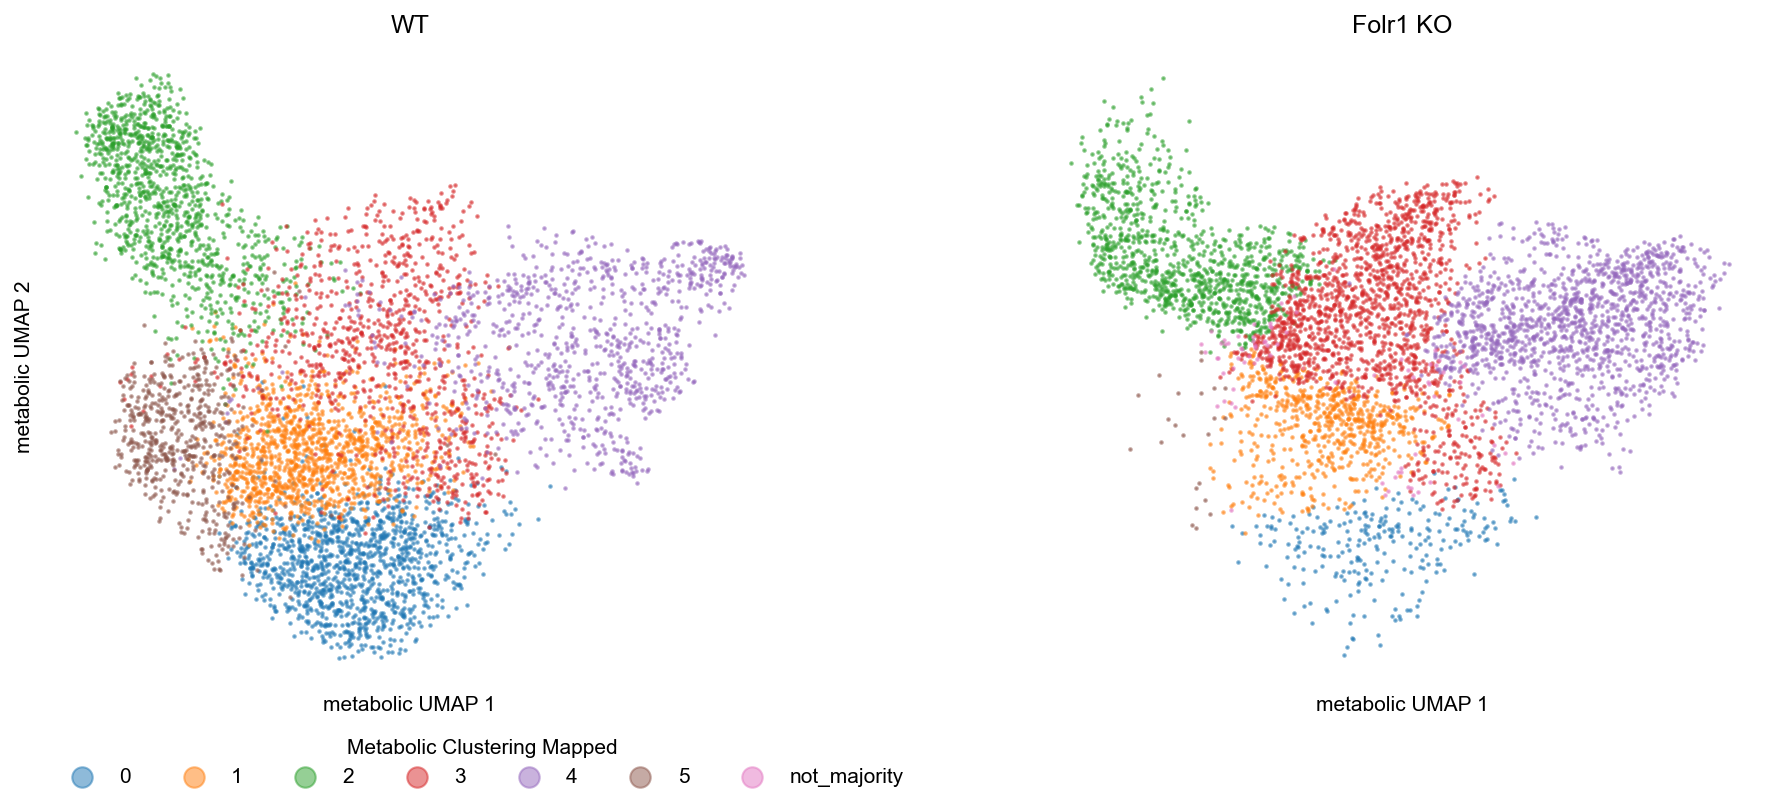

In [29]:
reset_plotting_defaults()

states = sorted(mapped_state_labels.unique())
state_colors = dict(zip(states, sns.color_palette('tab10', n_colors=len(states)).as_hex()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
for ax, (title, cells) in zip(axes, [('WT', wt_cells), ('Folr1 KO', folr1_cells)]):
    coords = mapped_umap.loc[cells]
    labels_here = mapped_state_labels.reindex(cells)
    for state in states:
        in_state = (labels_here == state).to_numpy()
        ax.scatter(
            coords.to_numpy()[in_state, 0],
            coords.to_numpy()[in_state, 1],
            s=1.5,
            alpha=0.5,
            color=state_colors[state],
            label=state if ax is axes[0] else None,
            rasterized=True,
        )
    ax.set_title(title)
    ax.set_xlabel('metabolic UMAP 1')
    ax.set_xticks([])
    ax.set_yticks([])
axes[0].set_ylabel('metabolic UMAP 2')
axes[0].legend(
    title='Metabolic Clustering Mapped', markerscale=8,
    bbox_to_anchor=(0, -0.05), loc='upper left', ncol=len(states),
)
sns.despine(fig, left=True, bottom=True)
fig.tight_layout()
plt.show()


### Rebuilding DDPs Within One Metabolic State

We compare metabolic state 2, which is made up primarily of epiblast and pre-gastrulation
progenitor cells.

Each genotype gets its own reaction-reaction correlation matrix, built from its own cells in that
state and its own replicate-averaged decode. Both are clustered over the *WT* graph at the same
threshold, so the only thing that differs between the two hierarchies is the correlation
structure.

Because DDPs are built by thresholding correlations, they are sensitive to how reaction activity was
estimated: a noisier estimate weakens every correlation, so fewer reactions clear the cutoff and the
programs come out smaller. This is why the tutorial uses activity averaged over many decodes rather
than a single one.

In [30]:
mapped_state = '2'
state_min_corr = 0.7

wt_state_cells = wt_cells[mapped_state_labels.reindex(wt_cells) == mapped_state]
folr1_state_cells = folr1_cells[mapped_state_labels.reindex(folr1_cells) == mapped_state]
print(f'metabolic state {mapped_state}: {len(wt_state_cells)} WT cells, '
      f'{len(folr1_state_cells)} Folr1 cells')

shared_rxns = wt_enzyme_acts_mean.columns
wt_state_acts = wt_enzyme_acts_mean.loc[wt_state_cells, shared_rxns]
folr1_state_acts = folr1_enzyme_acts_mean.loc[folr1_state_cells, shared_rxns]

flat = (wt_state_acts.std(axis=0) == 0) | (folr1_state_acts.std(axis=0) == 0)
print(f'{len(shared_rxns)} reactions, {int(flat.sum())} of them flat within the state '
      f'in at least one genotype')

wt_corr = wt_state_acts.corr(method='spearman')
folr1_corr = folr1_state_acts.corr(method='spearman')

wt_ddps, wt_ddp_rxns, _, wt_linkage = mern_support.calculate_ddps(
    met_g, wt_corr, min_corr=state_min_corr
)
folr1_ddps, folr1_ddp_rxns, _, folr1_linkage = mern_support.calculate_ddps(
    met_g, folr1_corr, min_corr=state_min_corr
)

print(f'WT DDPs in state {mapped_state}:    {len(wt_ddp_rxns)}')
print(f'Folr1 DDPs in state {mapped_state}: {len(folr1_ddp_rxns)}')

folate_rxns = ['rn:R04325 rn:R06974', 'rn:R04209']
folate_ddps = sorted(set(wt_ddps.reindex(folate_rxns).dropna()))
print('folate reactions:', {r: wt_ddps.get(r) for r in folate_rxns})
folate_ddp = folate_ddps[0] if len(folate_ddps) == 1 else None
if folate_ddp is None:
    print('the two folate reactions are not in a single WT DDP:', folate_ddps)


metabolic state 2: 1098 WT cells, 1071 Folr1 cells
1213 reactions, 0 of them flat within the state in at least one genotype
WT DDPs in state 2:    124
Folr1 DDPs in state 2: 134
folate reactions: {'rn:R04325 rn:R06974': 'ddp_59', 'rn:R04209': 'ddp_59'}


### WT DDPs Across Central Carbon and Nucleotide Metabolism

Before scoring what breaks, it helps to see what the WT programs *are*. We take every DDP that
touches glycolysis, pentose phosphate, purine, or pyrimidine metabolism and draw all of their
reactions on the reaction graph, colored by DDP membership. Each DDP is a connected, coordinated
block, and the layout separates the four pathway neighborhoods.

`folate_ddp` sits in purine metabolism: its reactions are consecutive steps of de novo purine
synthesis, the route that consumes a pentose phosphate pathway product to build the purine ring.

Only WT DDPs appear here. The knockout's own clustering is not used by this plot or the next one.

In [31]:
pathways_of_interest = ['rn00010', 'rn00030', 'rn00230', 'rn00240']

keep_ddps = set()
keep_rxns = set()
for rxn in shared_rxns:
    if rxn not in rxn_info.index:
        continue
    rxn_pathways = str(rxn_info.loc[rxn, 'Pathways']).split(';')
    if not set(rxn_pathways) & set(pathways_of_interest):
        continue
    keep_rxns.add(rxn)
    if rxn in wt_ddps.index and wt_ddps[rxn] is not None and not pd.isnull(wt_ddps[rxn]):
        keep_ddps.add(wt_ddps[rxn])

for ddp in keep_ddps:
    keep_rxns.update(wt_ddp_rxns[ddp])

keep_rxns = sorted(keep_rxns)
print(f'{len(keep_ddps)} DDPs touch the selected pathways, spanning {len(keep_rxns)} reactions')


22 DDPs touch the selected pathways, spanning 281 reactions


In [32]:
wt_labels = wt_ddps.where(wt_ddps.index.isin(keep_rxns), None)

keep_labels = metabolite_labels(dataset, rxns=keep_rxns, require_anchors=False)
print('labelled metabolites:', [dataset.compound_info[c.split('cpd:')[1]]['name'].split(';')[0]
                               for c in keep_labels])

with ddp_pathway_palette(wt_labels):
    fig = mern_support.custom_pathway_plot(
        rxns=keep_rxns,
        dataset=dataset,
        rna=rna,
        user_labels=wt_labels,
        show_node_labels=True,
        labeled_nodes=keep_labels,
    )
fig.update_layout(title='Selected reactions colored by WT DDP membership')
fig.write_image(f"{base_path_figures}/folr1_ddp_plot.png", width=1200, height=800, scale=2)
fig.show()


labelled metabolites: ['alpha-D-Glucose', 'D-Glucose', 'alpha-D-Glucose 6-phosphate', 'D-Fructose 6-phosphate', 'D-Fructose 1,6-bisphosphate', 'Glycerone phosphate', 'D-Glyceraldehyde 3-phosphate', '3-Phospho-D-glyceroyl phosphate', '3-Phospho-D-glycerate', '2-Phospho-D-glycerate', 'Phosphoenolpyruvate', 'Pyruvate', '(S)-Lactate']


![Folr1 DDP Plot](figures/folr1_ddp_plot.png)

### Weakest-Link Analysis Across Genotypes

We now run the structural-break calculation with WT as the reference state and *Folr1* as the
comparison state. Every reaction in a DDP is, by construction, correlated with its DDP partners in
WT; holding those groups fixed and recomputing the correlations in the knockout shows which pairs
the WT definition no longer describes.

Each point is a WT DDP. For each one we take the weakest correlation between any two of its
reactions in WT, and subtract the weakest correlation between any two of its reactions in the
knockout. The y-axis does this on the raw reaction correlations; the x-axis does it on the cophenetic
correlations, which registers whether the drop also reorganizes the clustering hierarchy. DDPs in the
upper right lose coordination in the knockout on both measures.

This is the weakest-link analysis of the paper's Methods. The two statistics are `min_corr_drop` and `min_cophenetic_drop` which drops the minimum raw and cophenetic correlation over all reaction pairs with a DDP.

`folate_ddp` is highlighted with the
top-ranked breaks labeled alongside it.

In [33]:
# A DDP with at least two reactions to work through. The folate DDP when it is well defined,
# otherwise the largest WT DDP in this metabolic state.
if folate_ddp is not None:
    focus_ddp = folate_ddp
else:
    focus_ddp = max(wt_ddp_rxns, key=lambda d: len(wt_ddp_rxns[d]))
    print(f'folate reactions did not form a single DDP; using the largest instead')

focus_rxns = [rxn for rxn in wt_ddp_rxns[focus_ddp] if rxn in wt_corr.index]
focus_pairs = list(itertools.combinations(focus_rxns, 2))
print(f'{focus_ddp}: {len(focus_rxns)} reactions, {len(focus_pairs)} pairs\n')

# Cophenetic correlations: the level at which each pair first joins in the hierarchy.
# The linkage stores distance as 1 - correlation, which this helper converts back.
labels = list(wt_corr.index)
wt_cophenetic = mern_support.calculate_cophenetic_corr_matrix(wt_linkage, labels)
folr1_cophenetic = mern_support.calculate_cophenetic_corr_matrix(folr1_linkage, labels)


def pair_values(matrix, pairs):
    """The matrix entry for each reaction pair, indexed by the pair."""
    return pd.Series({pair: matrix.loc[pair[0], pair[1]] for pair in pairs})


wt_raw = pair_values(wt_corr, focus_pairs)
folr1_raw = pair_values(folr1_corr, focus_pairs)
wt_coph = pair_values(wt_cophenetic, focus_pairs)
folr1_coph = pair_values(folr1_cophenetic, focus_pairs)

# The weakest link in each condition is the minimum over the DDP's pairs.
m_raw_wt, m_raw_folr1 = wt_raw.min(), folr1_raw.min()
m_coph_wt, m_coph_folr1 = wt_coph.min(), folr1_coph.min()

# The statistics are the drops from the reference condition to the alternate one.
delta_raw = m_raw_wt - m_raw_folr1
delta_coph = m_coph_wt - m_coph_folr1

print(f'weakest raw correlation        WT {m_raw_wt:6.3f}  ->  Folr1 {m_raw_folr1:6.3f}'
      f'   drop {delta_raw:+.3f}')
print(f'weakest cophenetic correlation WT {m_coph_wt:6.3f}  ->  Folr1 {m_coph_folr1:6.3f}'
      f'   drop {delta_coph:+.3f}')
print(f'\nweakest pair in WT:    {wt_raw.idxmin()}')
print(f'largest drop in a pair: {(wt_raw - folr1_raw).idxmax()} '
      f'({(wt_raw - folr1_raw).max():+.3f})')

ddp_59: 5 reactions, 10 pairs

weakest raw correlation        WT  0.896  ->  Folr1  0.528   drop +0.368
weakest cophenetic correlation WT  0.896  ->  Folr1 -0.202   drop +1.098

weakest pair in WT:    ('rn:R04144', 'rn:R04209')
largest drop in a pair: ('rn:R04144', 'rn:R04209') (+0.368)


In [34]:
folr1_breaks = mern_support.calculate_ddp_structural_breaks(
    wt_ddps,
    wt_corr,
    wt_linkage,
    folr1_corr,
    folr1_linkage,
)

display(folr1_breaks.sort_values('min_cophenetic_drop', ascending=False).head(10))

# the same two numbers derived by hand above for the DDP worked through there
focus_row = folr1_breaks.set_index('ddp').loc[focus_ddp]
assert np.isclose(focus_row['min_corr_drop'], delta_raw)
assert np.isclose(focus_row['min_cophenetic_drop'], delta_coph)
print(f'\n{focus_ddp}: hand-computed drops match calculate_ddp_structural_breaks')

,rank,ddp,n_reactions,n_pairs,wt_mean_corr,ko_mean_corr,mean_corr_drop,wt_min_corr,ko_min_corr,min_corr_drop,largest_corr_drop_pair,wt_mean_cophenetic_corr,ko_mean_cophenetic_corr,mean_cophenetic_drop,wt_min_cophenetic_corr,ko_min_cophenetic_corr,min_cophenetic_drop,largest_cophenetic_drop_pair,reactions
3,4,ddp_110,20,190,0.904171,0.907212,-0.003042,0.768065,0.655915,0.112150,"(rn:R01600 rn:R02187 rn:R09086, rn:R03418 rn:R...",0.823337,0.360658,0.462679,0.768065,-0.608656,1.376721,"(rn:R08639, rn:R00875)","[rn:R13199, rn:R00768, rn:R00760, rn:R00771, r..."
1,2,ddp_59,5,10,0.945682,0.778614,0.167068,0.896299,0.527922,0.368377,"(rn:R04144, rn:R04209)",0.932959,0.318744,0.614215,0.896299,-0.201650,1.097949,"(rn:R04144, rn:R04209)","[rn:R04144, rn:R04325 rn:R06974, rn:R04463, rn..."
0,1,ddp_81,8,28,0.876629,0.812823,0.063806,0.753695,0.644377,0.109318,"(rn:R00552 rn:R00557 rn:R11711, rn:R00111 rn:R...",0.822493,0.208167,0.614326,0.753695,-0.316902,1.070597,"(rn:R00551, rn:R00566)","[rn:R00551, rn:R00552 rn:R00557 rn:R11711, rn:..."
2,3,ddp_92,9,36,0.864091,0.871811,-0.007720,0.703419,0.739533,-0.036114,"(rn:R00348, rn:R01085)",0.817745,0.277360,0.540384,0.703419,-0.348938,1.052357,(rn:R00341 rn:R00345 rn:R00346 rn:R00431 rn:R0...,[rn:R00341 rn:R00345 rn:R00346 rn:R00431 rn:R0...
10,11,ddp_108,16,120,0.870404,0.805738,0.064665,0.709078,0.403542,0.305536,"(rn:R00286, rn:R01092)",0.840755,0.576330,0.264425,0.709078,-0.308496,1.017574,"(rn:R00959, rn:R00286)","[rn:R00959, rn:R00287 rn:R00289 rn:R00955, rn:..."
6,7,ddp_74,7,21,0.859400,0.764398,0.095002,0.796049,0.591325,0.204724,"(rn:R00238, rn:R02488)",0.831445,0.488105,0.343339,0.796049,-0.122791,0.918840,"(rn:R01171 rn:R01175, rn:R02488)","[rn:R00238, rn:R01978, rn:R01176 rn:R01179, rn..."
4,5,ddp_82,8,28,0.843397,0.797473,0.045924,0.749143,0.650002,0.099141,"(rn:R00253 rn:R00256, rn:R03905)",0.801608,0.363693,0.437915,0.749143,0.016681,0.732462,"(rn:R00484 rn:R01397, rn:R00670)","[rn:R00253 rn:R00256, rn:R00484 rn:R01397, rn:..."
12,13,ddp_117,25,300,0.914444,0.881556,0.032888,0.784049,0.493720,0.290329,"(rn:R00181, rn:R06604)",0.876337,0.634845,0.241492,0.784049,0.173747,0.610302,"(rn:R01770 rn:R01863, rn:R01768 rn:R01769)","[rn:R01127, rn:R01126 rn:R01131, rn:R01132, rn..."
5,6,ddp_3,3,3,0.890853,0.876454,0.014400,0.861252,0.816813,0.044439,"(rn:R03313, rn:R00669 rn:R02282)",0.887420,0.497315,0.390106,0.861252,0.296185,0.565067,"(rn:R00667, rn:R03313)","[rn:R00667, rn:R03313, rn:R00669 rn:R02282]"
7,8,ddp_75,7,21,0.801811,0.669029,0.132782,0.766196,0.476941,0.289255,"(rn:R01004, rn:R13444)",0.793968,0.472712,0.321256,0.766196,0.218786,0.547410,"(rn:R01009, rn:R13403)","[rn:R01009, rn:R01003 rn:R01018, rn:R01005 rn:..."



ddp_59: hand-computed drops match calculate_ddp_structural_breaks


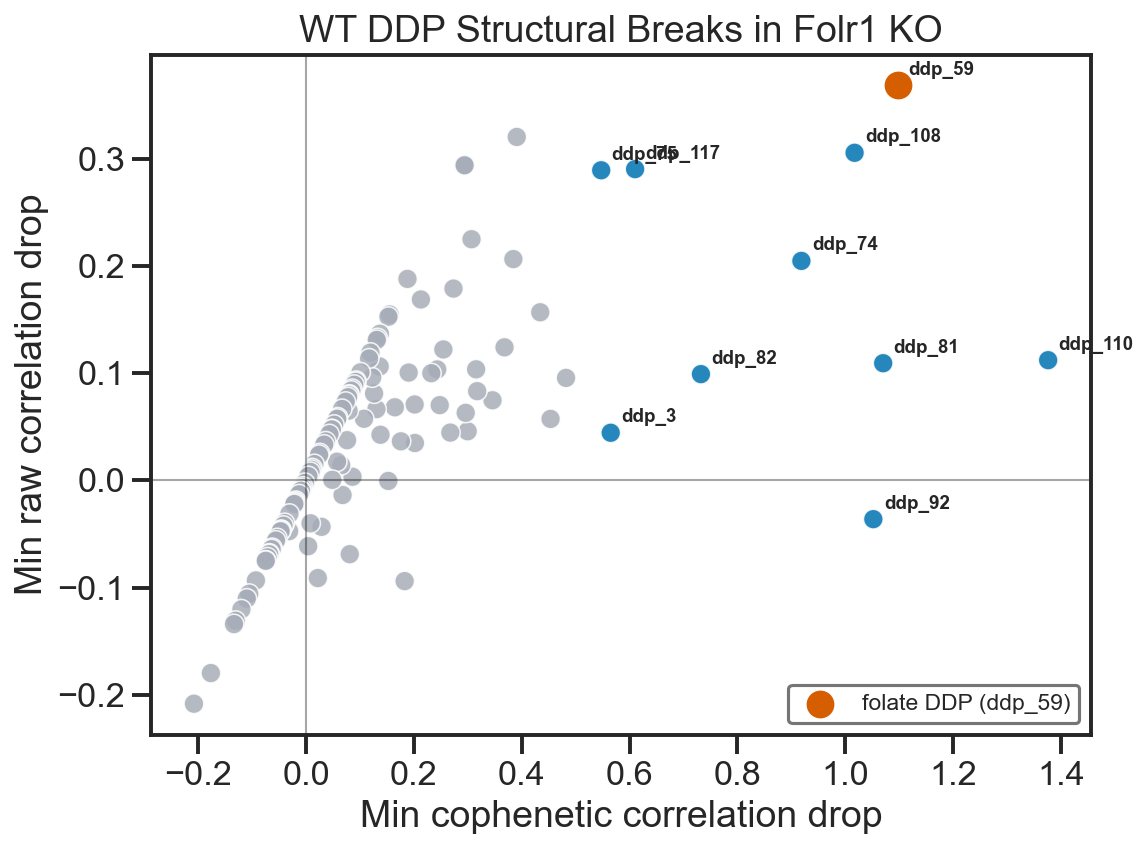

In [36]:
top_n = 10
folr1_breaks = folr1_breaks.copy()

folr1_breaks = folr1_breaks.sort_values("min_cophenetic_drop", ascending=False)
folr1_breaks["min_cophenetic_drop_rank"] = range(1, len(folr1_breaks) + 1)
folr1_breaks["is_top"] = folr1_breaks["min_cophenetic_drop_rank"] <= top_n
# folate_ddp is None when the two folate reactions did not land in a single WT DDP.
folr1_breaks["is_folate"] = (
    folr1_breaks["ddp"].astype(str).eq(str(folate_ddp)) if folate_ddp is not None else False
)

styled_theme(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=folr1_breaks,
    x="min_cophenetic_drop",
    y="min_corr_drop",
    hue="is_top",
    palette={True: OBSERVED_COLOR, False: BACKGROUND_COLOR},
    s=90,
    alpha=0.85,
    legend=False,
    ax=ax,
)

folate_row = folr1_breaks.loc[folr1_breaks["is_folate"]]
ax.scatter(
    folate_row["min_cophenetic_drop"],
    folate_row["min_corr_drop"],
    color=HIGHLIGHT_COLOR,
    s=140,
    zorder=5,
    label=f"folate DDP ({folate_ddp})",
)
if not folate_row.empty:
    ax.legend(
        frameon=True, fontsize=11, edgecolor=STRUCTURE_COLOR,
        facecolor='white', framealpha=0.9,
    )

ax.axhline(0, color="black", linewidth=1, alpha=0.35)
ax.axvline(0, color="black", linewidth=1, alpha=0.35)
ax.grid(False)

for _, row in folr1_breaks.loc[folr1_breaks["is_top"] | folr1_breaks["is_folate"]].iterrows():
    ax.annotate(
        str(row["ddp"]),
        (row["min_cophenetic_drop"], row["min_corr_drop"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        weight="bold",
    )

ax.set_title("WT DDP Structural Breaks in Folr1 KO")
ax.set_xlabel("Min cophenetic correlation drop")
ax.set_ylabel("Min raw correlation drop")

fig.tight_layout()
plt.show()
